# 00 Final LSTM Models (with Corrected Training, Validation, and Test Data Splits)
**Note: In all previous LSTM model notebooks, we have been using the wrong version of the dataset, which likely contributes to why we were getting such good metrics. We found this out quite late into the project, and we have corrected it here. However, the previous notebooks still use the incorrect data, as it would be too cumbersome to try and change all of it. For clarity, the error comes from the ordering of our data, as instead of ordering by Date first and then by Ticker, we reversed it. Thus, when creating our train/test split, our test dataset only used data from the last ~5 stocks, and it included all of their dates and times. This is in stark contrast to what we were aiming for - using the last XX days for all stocks (e.g., using the last 10 days for all 475 tickers to get 4,750 test datapoints).**

## Imports

In [670]:
import pandas as pd
import numpy as np
import yfinance as yf
from datetime import date
import matplotlib.pyplot as plt
import seaborn as sns
from mlxtend.plotting import heatmap

import tulipy as ti

import sklearn
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.decomposition import KernelPCA
from sklearn.decomposition import IncrementalPCA

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras import initializers
from tensorflow.keras.models import load_model
from tensorflow.keras.utils import register_keras_serializable
from tensorflow.keras.optimizers import SGD
import keras_tuner as kt
from keras_tuner import HyperParameters

import os
import sys
import warnings

# Data Loading and Initial Feature Engineering for LSTM Model

## Getting S&P500 Table Data

In [3]:
sp500_tables = pd.read_csv('../SP500_Tickers_March_2025.csv', index_col='Unnamed: 0')
sp500_tables.head()

,Symbol,Security,GICS Sector,GICS Sub-Industry,Headquarters Location,Date added,CIK,Founded
0,MMM,3M,Industrials,Industrial Conglomerates,"Saint Paul, Minnesota",1957-03-04,66740,1902
1,AOS,A. O. Smith,Industrials,Building Products,"Milwaukee, Wisconsin",2017-07-26,91142,1916
2,ABT,Abbott Laboratories,Health Care,Health Care Equipment,"North Chicago, Illinois",1957-03-04,1800,1888
3,ABBV,AbbVie,Health Care,Biotechnology,"North Chicago, Illinois",2012-12-31,1551152,2013 (1888)
4,ACN,Accenture,Information Technology,IT Consulting & Other Services,"Dublin, Ireland",2011-07-06,1467373,1989


## Loading in Data

In [4]:
# Loading in stock data
data = pd.read_csv("../SP500_4y_day_data.csv", index_col='Date', parse_dates=True)

In [5]:
# Converting Date_col to datetime format
data['Date_col'] = pd.to_datetime(data['Date_col'])

In [6]:
data

,Date_col,Ticker,Open,High,Low,Close,Volume,rank
Date,,,,,,,,
2021-01-04,2021-01-04,A,115.875028,116.995388,114.092184,115.582756,2030700.0,1.0
2021-01-05,2021-01-05,A,115.426870,117.219451,115.027432,116.527748,2344000.0,2.0
2021-01-06,2021-01-06,A,115.631454,120.687707,115.163820,119.723221,2428500.0,3.0
2021-01-07,2021-01-07,A,121.126122,124.194950,120.911790,122.908966,1775900.0,4.0
2021-01-08,2021-01-08,A,123.230471,124.350838,122.606963,123.785782,1577200.0,5.0
...,...,...,...,...,...,...,...,...
2024-12-24,2024-12-24,ZTS,163.206597,164.542554,162.249499,164.203583,1023600.0,1001.0
2024-12-26,2024-12-26,ZTS,163.226540,165.290293,162.528653,165.021118,2167200.0,1002.0
2024-12-27,2024-12-27,ZTS,164.452833,166.028073,163.027150,164.103897,1800100.0,1003.0


## Feature Engineering
Deriving multiple different features and outcome variables we can use in our model.

In [7]:
# Getting difference between close price and open price (outcome variables)
data["Close_Open_Diff"] = data["Close"] - data["Open"]
data["Close_Open_Diff_Perc"] = (data["Close"] - data["Open"]) / data["Open"] * 100

# Getting binary classification for whether a stock ended positive (1) or negative/zero (0)
data["Close_Open_Diff_Binary"] = data["Close_Open_Diff"] > 0

# Getting ternary classification for whether a stock ended positive (2), negative (0), or not much change (1)
close_open_conditions = [
    data['Close_Open_Diff_Perc'] > 0.5,       # Close price was at least 0.5% higher than Open price
    (data['Close_Open_Diff_Perc'] >= -0.5) &  # Close price was between -0.5% and 0.5% of Open price
        (data['Close_Open_Diff_Perc'] <= 0.5),
    data['Close_Open_Diff_Perc'] < -0.5       # Close price was at least 0.5% lower than Open price
]
close_open_choices = [2, 1, 0]  # Defining choices corresponding to conditions
data['Close_Open_Diff_Ternary'] = np.select(close_open_conditions, close_open_choices)  # Applying conditions

data

,Date_col,Ticker,Open,High,Low,Close,Volume,rank,Close_Open_Diff,Close_Open_Diff_Perc,Close_Open_Diff_Binary,Close_Open_Diff_Ternary
Date,,,,,,,,,,,,
2021-01-04,2021-01-04,A,115.875028,116.995388,114.092184,115.582756,2030700.0,1.0,-0.292272,-0.252231,False,1
2021-01-05,2021-01-05,A,115.426870,117.219451,115.027432,116.527748,2344000.0,2.0,1.100878,0.953745,True,2
2021-01-06,2021-01-06,A,115.631454,120.687707,115.163820,119.723221,2428500.0,3.0,4.091766,3.538627,True,2
2021-01-07,2021-01-07,A,121.126122,124.194950,120.911790,122.908966,1775900.0,4.0,1.782844,1.471891,True,2
2021-01-08,2021-01-08,A,123.230471,124.350838,122.606963,123.785782,1577200.0,5.0,0.555311,0.450628,True,1
...,...,...,...,...,...,...,...,...,...,...,...,...
2024-12-24,2024-12-24,ZTS,163.206597,164.542554,162.249499,164.203583,1023600.0,1001.0,0.996986,0.610874,True,2
2024-12-26,2024-12-26,ZTS,163.226540,165.290293,162.528653,165.021118,2167200.0,1002.0,1.794578,1.099440,True,2
2024-12-27,2024-12-27,ZTS,164.452833,166.028073,163.027150,164.103897,1800100.0,1003.0,-0.348936,-0.212180,False,1


Getting previous day metrics (since we don't know current day's metrics except open) and growth rates

In [8]:
# Getting the first actual trading day
first_trading_date = str(data.Date_col.idxmin().date())

# Getting growth rates and previous day OHLCV metrics
for x in data.columns[2:-6]:
  data[f'Growth Rate_{x}'] = (data[x] - data[x].shift(1))/data[x].shift(1) * 100
data["PDO"] = data["Open"].shift(1)
data["PDH"] = data["High"].shift(1)
data["PDL"] = data["Low"].shift(1)
data["PDC"] = data["Close"].shift(1)
data["PDV"] = data["Volume"].shift(1)

# For row in data, if date is first trading date, set above column values to null. Note: date is the index:
data.loc[first_trading_date, ['PDO', 'PDH', 'PDL', 'PDC', 'PDV', 'Growth Rate_Open', 'Growth Rate_High', 'Growth Rate_Low',
    'Growth Rate_Close']] = np.nan

data.head()

,Date_col,Ticker,Open,High,Low,Close,Volume,rank,Close_Open_Diff,Close_Open_Diff_Perc,...,Close_Open_Diff_Ternary,Growth Rate_Open,Growth Rate_High,Growth Rate_Low,Growth Rate_Close,PDO,PDH,PDL,PDC,PDV
Date,,,,,,,,,,,,,,,,,,,,,
2021-01-04,2021-01-04,A,115.875028,116.995388,114.092184,115.582756,2030700.0,1.0,-0.292272,-0.252231,...,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-01-05,2021-01-05,A,115.426870,117.219451,115.027432,116.527748,2344000.0,2.0,1.100878,0.953745,...,2,-0.386760,0.191515,0.819730,0.817589,115.875028,116.995388,114.092184,115.582756,2030700.0
2021-01-06,2021-01-06,A,115.631454,120.687707,115.163820,119.723221,2428500.0,3.0,4.091766,3.538627,...,2,0.177242,2.958772,0.118571,2.742242,115.426870,117.219451,115.027432,116.527748,2344000.0
2021-01-07,2021-01-07,A,121.126122,124.194950,120.911790,122.908966,1775900.0,4.0,1.782844,1.471891,...,2,4.751879,2.906048,4.991124,2.660925,115.631454,120.687707,115.163820,119.723221,2428500.0
2021-01-08,2021-01-08,A,123.230471,124.350838,122.606963,123.785782,1577200.0,5.0,0.555311,0.450628,...,1,1.737320,0.125518,1.401992,0.713386,121.126122,124.194950,120.911790,122.908966,1775900.0


Getting gap (i.e., change from some previous day metric) features and volume features

In [9]:
# Getting the opening gap features from PDC
data["Gap_from_PDC"] = (data["Open"] - data["PDC"]) / data["PDC"]
gap_from_PDC_threshold = 0.02  # 2%
data["Gap_Binary_Threshold"] = abs(data["Gap_from_PDC"]) > gap_from_PDC_threshold

# Getting daily range gap up features
data["Daily_Range_Gap_Up"] = (data["Open"] - data["PDH"]) / data["PDH"]
data["Daily_Range_Gap_Up"] = data["Daily_Range_Gap_Up"].clip(lower = 0)
data["DR_Gap_Up_Binary"] = data["Daily_Range_Gap_Up"] > 0

# Getting daily range gap down features
data["Daily_Range_Gap_Down"] = (data["Open"] - data["PDL"]) / data["PDL"]
data["Daily_Range_Gap_Down"] = data["Daily_Range_Gap_Down"].clip(upper = 0)
data["DR_Gap_Down_Binary"] = data["Daily_Range_Gap_Down"] < 0

# Getting 14-day average volume and previous volume features
avg_vol_window = 14
data["Avg_Volume_14D"] = data["Volume"].rolling(window=avg_vol_window).mean()
data["Avg_Vol_Prev_14D"] = data["PDV"].rolling(window=avg_vol_window).mean()

# Comparing current volume to average volume over the past XX days
data["Vol_Change"] = (data["Volume"] - data["Avg_Vol_Prev_14D"]) / data["Avg_Vol_Prev_14D"]

# Setting the first 14-day volume averages and previous averages of every ticker to np.nan
data.loc[data["rank"] < 15, ["Avg_Volume_14D", "Avg_Vol_Prev_14D", "Vol_Change"]] = np.nan

data[10:20]

,Date_col,Ticker,Open,High,Low,Close,Volume,rank,Close_Open_Diff,Close_Open_Diff_Perc,...,PDV,Gap_from_PDC,Gap_Binary_Threshold,Daily_Range_Gap_Up,DR_Gap_Up_Binary,Daily_Range_Gap_Down,DR_Gap_Down_Binary,Avg_Volume_14D,Avg_Vol_Prev_14D,Vol_Change
Date,,,,,,,,,,,,,,,,,,,,,
2021-01-19,2021-01-19,A,124.097539,124.506722,123.035631,124.068314,1677200.0,11.0,-0.029226,-0.023551,...,2115400.0,0.009270,False,0.002045,True,0.000000,False,NaN,NaN,NaN
2021-01-20,2021-01-20,A,124.419037,125.597856,124.078058,124.808731,1843000.0,12.0,0.389694,0.313211,...,1677200.0,0.002827,False,0.000000,False,0.000000,False,NaN,NaN,NaN
2021-01-21,2021-01-21,A,124.477480,125.461455,123.162270,123.727325,1612100.0,13.0,-0.750155,-0.602643,...,1843000.0,-0.002654,False,0.000000,False,0.000000,False,NaN,NaN,NaN
2021-01-22,2021-01-22,A,123.805281,124.506729,123.045382,123.074608,1438700.0,14.0,-0.730673,-0.590179,...,1612100.0,0.000630,False,0.000000,False,0.000000,False,NaN,NaN,NaN
2021-01-25,2021-01-25,A,123.425324,124.194968,121.223560,122.246506,1365400.0,15.0,-1.178819,-0.955086,...,1438700.0,0.002850,False,0.000000,False,0.000000,False,1.728993e+06,1.776514e+06,-0.231416
2021-01-26,2021-01-26,A,122.265994,122.704395,120.678000,120.726707,1476600.0,16.0,-1.539287,-1.258966,...,1365400.0,0.000159,False,0.000000,False,0.000000,False,1.667036e+06,1.728993e+06,-0.145977
2021-01-27,2021-01-27,A,118.934108,119.830399,115.066411,115.738632,1923500.0,17.0,-3.195476,-2.686762,...,1476600.0,-0.014848,False,0.000000,False,-0.014451,True,1.630964e+06,1.667036e+06,0.153845
2021-01-28,2021-01-28,A,115.933484,119.508910,115.719152,118.427513,1677900.0,18.0,2.494029,2.151258,...,1923500.0,0.001684,False,0.000000,False,0.000000,False,1.623964e+06,1.630964e+06,0.028778
2021-01-29,2021-01-29,A,118.086527,118.554161,116.206261,117.073326,1822000.0,19.0,-1.013201,-0.858016,...,1677900.0,-0.002879,False,0.000000,False,0.000000,False,1.641450e+06,1.623964e+06,0.121946


Getting technical and momentum indicators

In [10]:
# SMA and EMA including this period
data["SMA_14"] = data["Close"].rolling(window=14).mean()
data["SMA_50"] = data["Close"].rolling(window=50).mean()
data["SMA_200"] = data["Close"].rolling(window=200).mean()
data["EMA_9"] = data["Close"].ewm(span=9, adjust=False).mean()
data["EMA_20"] = data["Close"].ewm(span=20, adjust=False).mean()

# SMA and EMA for the past XXX periods
data["SMA_prev_14"] = data["PDC"].rolling(window=14).mean()
data["SMA_prev_50"] = data["PDC"].rolling(window=50).mean()
data["SMA_prev_200"] = data["PDC"].rolling(window=200).mean()
data["EMA_prev_9"] = data["PDC"].ewm(span=9, adjust=False).mean()
data["EMA_prev_20"] = data["PDC"].ewm(span=20, adjust=False).mean()

# RSI Calculation
delta = data["Close"].diff()
gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()
rs = gain / loss
data["RSI_14"] = 100 - (100 / (1 + rs))

# RSI for the previous XX periods using tulipy
rsi_prev_14 = ti.rsi(data["PDC"].to_numpy(), 14)
nan_array_rsi = np.full(14, np.nan)
rsi_prev_14 = np.concatenate((nan_array_rsi, rsi_prev_14))
data["RSI_prev_14"] = rsi_prev_14

# ATR Calculation
data["ATR_14"] = (data["PDH"] - data["PDL"]).rolling(window=14).mean()
data["NATR_14"] = (data["ATR_14"] / data["PDC"]) * 100

# Setting 9, 14, 20, 50, and 200 day metrics to np.nan:
data.loc[data["rank"] <= 9, ['EMA_9', 'EMA_prev_9']] = np.nan
data.loc[data["rank"] <= 14, ['SMA_14', 'SMA_prev_14', 'RSI_14', 'RSI_prev_14', 'ATR_14', 'NATR_14']] = np.nan
data.loc[data["rank"] <= 20, ['EMA_20', 'EMA_prev_20']] = np.nan
data.loc[data["rank"] <= 50, ['SMA_50', 'SMA_prev_50']] = np.nan
data.loc[data["rank"] <= 200, ['SMA_200', 'SMA_prev_200']] = np.nan

data[:18]

,Date_col,Ticker,Open,High,Low,Close,Volume,rank,Close_Open_Diff,Close_Open_Diff_Perc,...,EMA_20,SMA_prev_14,SMA_prev_50,SMA_prev_200,EMA_prev_9,EMA_prev_20,RSI_14,RSI_prev_14,ATR_14,NATR_14
Date,,,,,,,,,,,,,,,,,,,,,
2021-01-04,2021-01-04,A,115.875028,116.995388,114.092184,115.582756,2030700.0,1.0,-0.292272,-0.252231,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-01-05,2021-01-05,A,115.426870,117.219451,115.027432,116.527748,2344000.0,2.0,1.100878,0.953745,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-01-06,2021-01-06,A,115.631454,120.687707,115.163820,119.723221,2428500.0,3.0,4.091766,3.538627,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-01-07,2021-01-07,A,121.126122,124.194950,120.911790,122.908966,1775900.0,4.0,1.782844,1.471891,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-01-08,2021-01-08,A,123.230471,124.350838,122.606963,123.785782,1577200.0,5.0,0.555311,0.450628,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-01-11,2021-01-11,A,123.191505,126.007032,122.977180,124.847694,1746800.0,6.0,1.656190,1.344403,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-01-12,2021-01-12,A,125.023060,125.081511,122.947943,123.698105,1826400.0,7.0,-1.324955,-1.059768,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-01-13,2021-01-13,A,124.175467,124.750267,123.474019,123.707840,1530400.0,8.0,-0.467627,-0.376585,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-01-14,2021-01-14,A,123.990362,124.886660,122.577731,122.782318,924900.0,9.0,-1.208044,-0.974305,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [11]:
# Getting the sector for stocks as another feature
ticker_and_sector = sp500_tables[['Symbol', 'GICS Sector']]

# Getting the GICS sector into the table through a merge function
data = data.reset_index().merge(ticker_and_sector, left_on='Ticker', right_on='Symbol', how='left').set_index('Date')
data = data.drop(columns=['Symbol'])

# Replacing NaN GICS Sectors with Other
data['GICS Sector'] = data['GICS Sector'].fillna('Other')

data.head()

,Date_col,Ticker,Open,High,Low,Close,Volume,rank,Close_Open_Diff,Close_Open_Diff_Perc,...,SMA_prev_14,SMA_prev_50,SMA_prev_200,EMA_prev_9,EMA_prev_20,RSI_14,RSI_prev_14,ATR_14,NATR_14,GICS Sector
Date,,,,,,,,,,,,,,,,,,,,,
2021-01-04,2021-01-04,A,115.875028,116.995388,114.092184,115.582756,2030700.0,1.0,-0.292272,-0.252231,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Health Care
2021-01-05,2021-01-05,A,115.426870,117.219451,115.027432,116.527748,2344000.0,2.0,1.100878,0.953745,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Health Care
2021-01-06,2021-01-06,A,115.631454,120.687707,115.163820,119.723221,2428500.0,3.0,4.091766,3.538627,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Health Care
2021-01-07,2021-01-07,A,121.126122,124.194950,120.911790,122.908966,1775900.0,4.0,1.782844,1.471891,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Health Care
2021-01-08,2021-01-08,A,123.230471,124.350838,122.606963,123.785782,1577200.0,5.0,0.555311,0.450628,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Health Care


In [12]:
# Getting date index column:
date_index = data.index.sort_values()

# Dropping duplicates:
date_index = date_index.drop_duplicates()

date_index

DatetimeIndex(['2021-01-04', '2021-01-05', '2021-01-06', '2021-01-07',
               '2021-01-08', '2021-01-11', '2021-01-12', '2021-01-13',
               '2021-01-14', '2021-01-15',
               ...
               '2024-12-17', '2024-12-18', '2024-12-19', '2024-12-20',
               '2024-12-23', '2024-12-24', '2024-12-26', '2024-12-27',
               '2024-12-30', '2024-12-31'],
              dtype='datetime64[ns]', name='Date', length=1005, freq=None)

## Selecting Base Features
Of the features we created, we select only the ones that we intend on using.

In [13]:
data.columns

Index(['Date_col', 'Ticker', 'Open', 'High', 'Low', 'Close', 'Volume', 'rank',
       'Close_Open_Diff', 'Close_Open_Diff_Perc', 'Close_Open_Diff_Binary',
       'Close_Open_Diff_Ternary', 'Growth Rate_Open', 'Growth Rate_High',
       'Growth Rate_Low', 'Growth Rate_Close', 'PDO', 'PDH', 'PDL', 'PDC',
       'PDV', 'Gap_from_PDC', 'Gap_Binary_Threshold', 'Daily_Range_Gap_Up',
       'DR_Gap_Up_Binary', 'Daily_Range_Gap_Down', 'DR_Gap_Down_Binary',
       'Avg_Volume_14D', 'Avg_Vol_Prev_14D', 'Vol_Change', 'SMA_14', 'SMA_50',
       'SMA_200', 'EMA_9', 'EMA_20', 'SMA_prev_14', 'SMA_prev_50',
       'SMA_prev_200', 'EMA_prev_9', 'EMA_prev_20', 'RSI_14', 'RSI_prev_14',
       'ATR_14', 'NATR_14', 'GICS Sector'],
      dtype='object')

In [14]:
# Getting a copy of the data to work with so we don't ruin original
data_small = data.copy()

# Removing BIIB ticker in general (since it's missing data for one of the trading days)
data_small = data_small[data_small['Ticker'] != 'BIIB']

# If rank is less than or equal to the number of NA_days, drop the row (since there will be NaN data)
NA_days = 50  # Choosing 50 for SMA_prev_50
data_small = data_small[data_small['rank'] > NA_days]

# Only keeping certain columns
data_small_columns_keep = ['Date_col', 'Ticker', 'Open', 'PDO', 'PDH', 'PDL', 'PDC', 'PDV', 'Gap_from_PDC', 'Gap_Binary_Threshold',
    'Daily_Range_Gap_Up', 'DR_Gap_Up_Binary', 'Daily_Range_Gap_Down', 'DR_Gap_Down_Binary', 'Avg_Vol_Prev_14D', 'Vol_Change',
    'SMA_prev_14', 'SMA_prev_50', 'EMA_prev_9', 'EMA_prev_20', 'RSI_prev_14', 'NATR_14', 'GICS Sector', 'Close_Open_Diff_Perc',
    'Close_Open_Diff_Ternary']

data_small = data_small[data_small_columns_keep]

data_small.describe()

,Date_col,Open,PDO,PDH,PDL,PDC,PDV,Gap_from_PDC,Daily_Range_Gap_Up,Daily_Range_Gap_Down,Avg_Vol_Prev_14D,Vol_Change,SMA_prev_14,SMA_prev_50,EMA_prev_9,EMA_prev_20,RSI_prev_14,NATR_14,Close_Open_Diff_Perc,Close_Open_Diff_Ternary
count,453625,453625.000000,453625.000000,453625.000000,453625.000000,453625.000000,4.536250e+05,453625.000000,453625.000000,453625.000000,4.536250e+05,453625.000000,453625.000000,453625.000000,453625.000000,453625.000000,453625.000000,453625.000000,453625.000000,453625.000000
mean,2023-02-06 10:24:15.078533888,167.796289,167.735657,169.605319,165.838671,167.744599,5.939897e+06,0.000309,0.001013,-0.000990,5.951962e+06,0.023919,167.312294,165.962688,167.479749,167.087536,51.783003,2.362572,0.008622,1.011241
min,2021-03-17 00:00:00,1.010000,1.010000,1.040000,0.780000,0.980000,6.300000e+03,-0.388039,0.000000,-0.386389,1.150000e+04,-0.915551,1.055000,1.203000,1.059442,1.095938,3.203542,0.212823,-50.071084,0.000000
25%,2022-02-24 00:00:00,51.142663,51.130001,51.703654,50.546797,51.130585,9.969000e+05,-0.003835,0.000000,0.000000,1.094914e+06,-0.263134,51.035951,50.821200,51.097153,51.034005,43.036001,1.748904,-0.845422,0.000000
50%,2023-02-07 00:00:00,97.997940,97.980003,99.150002,96.781114,97.964836,2.042700e+06,0.000411,0.000000,0.000000,2.154914e+06,-0.083369,97.879983,97.531522,97.929508,97.831366,51.785360,2.163510,0.025686,1.000000
75%,2024-01-22 00:00:00,187.732867,187.665114,189.720001,185.619995,187.674515,4.692700e+06,0.004637,0.000000,0.000000,4.816121e+06,0.161837,187.518051,186.307378,187.644120,187.424250,60.554521,2.738881,0.871954,2.000000
max,2024-12-31 00:00:00,9914.169922,9914.169922,9964.769531,9794.000000,9924.400391,1.543911e+09,0.536680,0.391608,0.000000,7.066849e+08,25.587868,9677.040737,9442.719980,9744.845871,9637.574378,96.316095,18.195811,32.653064,2.000000
std,NaN,354.722275,354.475111,358.475832,350.625212,354.573813,2.411370e+07,0.011125,0.004844,0.005323,2.313540e+07,0.534852,352.761797,347.020647,353.412287,351.684981,12.172738,0.911041,1.619073,0.828860


In [15]:
# Getting some percent changes for the PDC compared to PDO for the first 5 values of data_small
data_small.iloc[0:5]['PDC'] / data_small.iloc[0:5]['PDO']
# These values will be a good litmus test to confirm that our normalization kept our percent differences between price values

Date
2021-03-17    0.985972
2021-03-18    1.001471
2021-03-19    0.991828
2021-03-22    0.998535
2021-03-23    1.011787
dtype: float64

In [16]:
# Doing the same, but for volume
data_small.iloc[0:5]['PDV'] / data_small.iloc[0:5]['Avg_Vol_Prev_14D']

Date
2021-03-17    0.737364
2021-03-18    0.795588
2021-03-19    1.125113
2021-03-22    1.350650
2021-03-23    0.905052
dtype: float64

In [17]:
# Defining a function to normalize the prices/volume to the max (*2) of every ticker
def normalize_to_max_per_ticker(df, col_list):
    df_normalized = df.copy()

    # Grouping by Ticker and getting the max values for either price or volume by ticker
    max_vals = df_normalized.groupby('Ticker')[col_list].transform('max').max(axis=1)

    # Applying normalization to entire df by dividing by max values for each ticker and then multiplying by 2
    df_normalized[col_list] = df_normalized[col_list].div(max_vals, axis=0) * 2

    return df_normalized

# Note: We normalize to the maximum (instead of using MinMax) of each ticker in order to preserve the same % changes as the unnormalized
# value. In our case, our normalized maximum will be 2, so our values will range from (down to) 0 to 2

In [18]:
# Normalizing the following columns to the global maximum prices (by percent compared to max price) for each ticker 
# ^e.g., if OHLC for a day is 2, 3, 1, 4, respectively, then their normalized versions would be 1, 1.5, 0.5, 2, respectively for that day
price_cols_to_norm = ['Open', 'PDO', 'PDH', 'PDL', 'PDC', 'SMA_prev_14', 'SMA_prev_50', 'EMA_prev_9', 'EMA_prev_20']
data_small = normalize_to_max_per_ticker(data_small, price_cols_to_norm)

# Normalizing volumes for all dates to the global maximum volume (by percent compared to max volume) for each ticker
volume_cols_to_norm = ['PDV', 'Avg_Vol_Prev_14D']
data_small = normalize_to_max_per_ticker(data_small, volume_cols_to_norm)

# Normalizing the following columns as percent (currently these are decimal changes) (except Vol_Change)
cols_to_perc = ['Gap_from_PDC', 'Daily_Range_Gap_Up', 'Daily_Range_Gap_Down']
data_small.loc[:, cols_to_perc] = data_small.loc[:, cols_to_perc] * 100

# Normalizing RSI to be between 0 and 1
data_small.loc[:, ['RSI_prev_14']] = data_small.loc[:, ['RSI_prev_14']] / 100

data_small.describe()

,Date_col,Open,PDO,PDH,PDL,PDC,PDV,Gap_from_PDC,Daily_Range_Gap_Up,Daily_Range_Gap_Down,Avg_Vol_Prev_14D,Vol_Change,SMA_prev_14,SMA_prev_50,EMA_prev_9,EMA_prev_20,RSI_prev_14,NATR_14,Close_Open_Diff_Perc,Close_Open_Diff_Ternary
count,453625,453625.000000,453625.000000,453625.000000,453625.000000,453625.000000,453625.000000,453625.000000,453625.000000,453625.000000,453625.000000,453625.000000,453625.000000,453625.000000,453625.000000,453625.000000,453625.000000,453625.000000,453625.000000,453625.000000
mean,2023-02-06 10:24:15.078533888,1.352334,1.352055,1.367110,1.336596,1.351941,0.331648,0.030902,0.101300,-0.098990,0.332086,0.023919,1.349815,1.342335,1.350641,1.348760,0.517830,2.362572,0.008622,1.011241
min,2021-03-17 00:00:00,0.053784,0.053784,0.056452,0.052552,0.053707,0.008487,-38.803893,0.000000,-38.638898,0.013925,-0.915551,0.063100,0.073716,0.060571,0.069261,0.032035,0.212823,-50.071084,0.000000
25%,2022-02-24 00:00:00,1.126022,1.125793,1.140061,1.112043,1.126120,0.181249,-0.383452,0.000000,0.000000,0.206541,-0.263134,1.125616,1.122068,1.126414,1.126401,0.430360,1.748904,-0.845422,0.000000
50%,2023-02-07 00:00:00,1.391997,1.391661,1.407153,1.375842,1.391571,0.287909,0.041106,0.000000,0.000000,0.315782,-0.083369,1.389664,1.383033,1.390428,1.389124,0.517854,2.163510,0.025686,1.000000
75%,2024-01-22 00:00:00,1.615531,1.615151,1.631728,1.597817,1.614908,0.424620,0.463727,0.000000,0.000000,0.437228,0.161837,1.611993,1.602763,1.613052,1.610022,0.605545,2.738881,0.871954,2.000000
max,2024-12-31 00:00:00,2.000000,2.000000,2.000000,1.991389,1.999860,2.000000,53.667959,39.160845,0.000000,1.396082,25.587868,1.993995,2.000000,1.994551,2.000000,0.963161,18.195811,32.653064,2.000000
std,NaN,0.345995,0.345914,0.347798,0.343587,0.345700,0.222903,1.112548,0.484430,0.532302,0.169022,0.534852,0.343052,0.335889,0.343385,0.340425,0.121727,0.911041,1.619073,0.828860


In [19]:
# Double checking data_small shows us that we do indeed keep % differences between price features on the same day even after normalization
data_small.iloc[0:5]['PDC'] / data_small.iloc[0:5]['PDO']

Date
2021-03-17    0.985972
2021-03-18    1.001471
2021-03-19    0.991828
2021-03-22    0.998535
2021-03-23    1.011787
dtype: float64

In [20]:
# And we see that we also keep % differences between the two volume features on the same day after normalization
data_small.iloc[0:5]['PDV'] / data_small.iloc[0:5]['Avg_Vol_Prev_14D']

Date
2021-03-17    0.737364
2021-03-18    0.795588
2021-03-19    1.125113
2021-03-22    1.350650
2021-03-23    0.905052
dtype: float64

In [21]:
# Ordering by date, and then by ticker to get the right splits for train/val/test
data_small = data_small.sort_values(by=['Date_col', 'Ticker'])

## Creating Dummy Variables for GICS Sector

In [22]:
# Getting a copy of data_small called data_smaller
data_smaller = data_small.copy()

In [23]:
# Getting dummy variables for GICS Sector
sector_dummy = pd.get_dummies(
    data_smaller['GICS Sector'],
    drop_first = False
)
print("Number of data_smaller dummy variables:", data_smaller['GICS Sector'].nunique())
print("Shape of data_smaller dummy variable for GICS Sector:",
      sector_dummy.shape, '\n')

# Adding the dummy variables to data_smaller
data_smaller = pd.concat(
    [data_smaller, sector_dummy],
    axis=1
)

Number of data_smaller dummy variables: 12
Shape of data_smaller dummy variable for GICS Sector: (453625, 12) 



In [24]:
# Checking to make sure dummies were created correctly
data_smaller.head(3)

,Date_col,Ticker,Open,PDO,PDH,PDL,PDC,PDV,Gap_from_PDC,Gap_Binary_Threshold,...,Consumer Staples,Energy,Financials,Health Care,Industrials,Information Technology,Materials,Other,Real Estate,Utilities
Date,,,,,,,,,,,,,,,,,,,,,
2021-03-17,2021-03-17,A,1.358732,1.385498,1.391718,1.359954,1.366062,0.274100,-0.536577,False,...,False,False,False,True,False,False,False,False,False,False
2021-03-17,2021-03-17,AAL,1.848984,1.924875,1.935608,1.863549,1.875814,0.577977,-1.430317,False,...,False,False,False,False,False,False,False,True,False,False
2021-03-17,2021-03-17,AAP,1.455625,1.470280,1.472615,1.427039,1.442258,0.090444,0.926817,False,...,False,False,False,False,False,False,False,True,False,False


In [25]:
# Removing GICS Sector since we've converted it to one-hot encoding
data_smaller = data_smaller.drop("GICS Sector", axis = 1)

print("Shape of data_smaller after removing original GICS Sector feature:",
      data_smaller.shape)

Shape of data_smaller after removing original GICS Sector feature: (453625, 36)


# LSTM Model with Corrected 99/1 Train/Test Split
This model involves using as much data as possible for training (from 2021-2024), and then using the last 10 days of 2024 for our testing data. This was originally our chosen final model before we realized our mistake with splitting the data.

## Function for Creating Sequences for LSTM Model
This is used to create our X and Y sequences in the LSTM model.

***NOTE: In previous notebooks, we did not have the "NEW ADDITION" code at the bottom, which means that our numpy arrays were sorted first by ticker, and then by date, rather than the other way around. What this means for all of our previous experiments involving this function is that our test dataset was essentially just the last few dates of the last (few) tickers (e.g., 12/15/24 - 12/31/24 for just ZTS). This is obviously not how we want our predictions to go, and we want to be able to predict ALL tickers, not just the last one. Therefore, our results previously could be considered null and void. However, because we were able to get decent validation accuracies, and because we still trained on roughly the same data, perhaps we will still get similar results. We will re-run the model and re-test our data to see if this is truly the case.**

In [320]:
# Function for creating sequences for LSTM model
def create_sequences_grouped(df, seq_length, group_col, target_col, drop_cols):
    """Create LSTM sequences separately for each unique ticker in the dataset."""
    X, Y = [], []
    num_tickers = df['Ticker'].nunique()
    
    # Group data by unique time series identifier (i.e., 'Ticker')
    grouped = df.groupby(group_col)
    
    for _, group in grouped:
        # Sorting by Date_col and removing the 'Ticker' column and dropped columns
        group = group.sort_values(by='Date_col')
        group = group.drop(columns=drop_cols)
        group = group.drop(columns=[group_col])

        # Getting feature and label columns
        feature_cols = group.drop(columns=[target_col]).columns
        feature_data = group[feature_cols].values
        labels = group[target_col].values
        
        # Creating sequences for this group only
        for i in range(len(group) - seq_length + 1):
            X.append(feature_data[i:i+seq_length])  # Collecting seq_length time steps
            Y.append(labels[i+seq_length-1])   # Target label is the most recent time step

    # Converting dtypes to the correct dtype
    X = np.array(X)
    X = X.astype(np.float32)
    Y = np.array(Y)
    Y = Y.astype(np.int32)

    # NEW ADDITION: Correctly re-ordering data first by the date, and THEN by the ticker
    indices_by_date_then_ticker = np.arange(X.shape[0]).reshape((num_tickers, -1)).flatten('F')
    X = X[indices_by_date_then_ticker]
    Y = Y[indices_by_date_then_ticker]
    
    return X, Y

## LSTM Classification (all stocks, longer series, smaller test and validation data sizes)
I.e., We'll be using all stocks and their GICS Sectors as futures, we'll extend our sequence length to 35 days, and we'll continue with our 99/1 train/test split.

### Generating X continuous series sequences, Y continuous labels, and splitting data into train and test sets

In [328]:
# Creating sequences for LSTM model
seq_length = 35
group_col = 'Ticker'
target_col = 'Close_Open_Diff_Ternary'
drop_cols = ['Date_col', 'Close_Open_Diff_Perc']

X_data_smaller, Y_data_smaller = create_sequences_grouped(data_smaller, seq_length, group_col, target_col, drop_cols)

In [329]:
# Confirming shapes
print('Shape of X_data_smaller:', X_data_smaller.shape)
print('Shape of Y_data_smaller:', Y_data_smaller.shape, '\n')

# Confirming that we should have the correct number of sequences in X_data_smaller
unique_tickers = data_smaller['Ticker'].nunique()
unique_dates = data_smaller['Date_col'].nunique()
expected_num_sequences = unique_tickers * (unique_dates - seq_length + 1)

print('Number of unique tickers in data_smaller:', unique_tickers)
print('Number of unique dates in data_smaller:', unique_dates)
print('Chosen sequence length:', seq_length)
print('Number of sequences assuming the above seq_length:', unique_dates - seq_length + 1)
print('(We need to add 1 to the end to account for either the beginning or the end. For example, if we had 12 observations with a window')
print('of 5, we would need 12 - 5 + 1 = 8 sequences, the first one being having indices from [0:5], and the last from [7:12].)\n')
print('Total number of data sequences expected:', expected_num_sequences)
print('Total number of data sequences achieved:', X_data_smaller.shape[0])

Shape of X_data_smaller: (437475, 35, 32)
Shape of Y_data_smaller: (437475,) 

Number of unique tickers in data_smaller: 475
Number of unique dates in data_smaller: 955
Chosen sequence length: 35
Number of sequences assuming the above seq_length: 921
(We need to add 1 to the end to account for either the beginning or the end. For example, if we had 12 observations with a window
of 5, we would need 12 - 5 + 1 = 8 sequences, the first one being having indices from [0:5], and the last from [7:12].)

Total number of data sequences expected: 437475
Total number of data sequences achieved: 437475


In [330]:
# Getting the number of sequences per ticker (same calculation as above, but now defined in a variable)
num_sequences_per_ticker = unique_dates - seq_length + 1

# Splitting the data into train and test sets
num_train_seq_int = int(0.99 * num_sequences_per_ticker)  # Need int split to separate correct number of sequences for train and test data
train_size = num_train_seq_int * unique_tickers  # Another way to think about it: regardless of the num_train_seq_int value, we need to go
# ^up by the number of tickers (e.g., 400) at an integer amount each time
X_train = X_data_smaller[:train_size]
Y_train = Y_data_smaller[:train_size]
X_test = X_data_smaller[train_size:]
Y_test = Y_data_smaller[train_size:]

# Confirming shapes
print('Shape of X_train:', X_train.shape)
print('Shape of Y_train:', Y_train.shape)
print('Shape of X_test:', X_test.shape)
print('Shape of Y_test:', Y_test.shape, '\n')

# Confirming number of dates
print('Number of dates in X_train:', num_train_seq_int)
print('Number of dates in X_test:', num_sequences_per_ticker - num_train_seq_int)

Shape of X_train: (432725, 35, 32)
Shape of Y_train: (432725,)
Shape of X_test: (4750, 35, 32)
Shape of Y_test: (4750,) 

Number of dates in X_train: 911
Number of dates in X_test: 10


### Building and compiling LSTM model

In [482]:
# Defining a weighting function to use as our loss function for higher weights towards certain classes (not used here)
@register_keras_serializable()
def weighted_sparse_categorical_crossentropy(weights):
    # Setting the weights as a tf tensor
    weights = tf.constant(weights, dtype=tf.float32)

    # Getting the loss function that we will return to the model
    def loss_fn(y_true, y_pred):
        y_true = tf.cast(y_true, tf.int32)  # Ensuring the correct shape
        sample_weights = tf.gather(weights, y_true)  # Getting weight for each sample based on its true class
        unweighted_loss = tf.keras.losses.sparse_categorical_crossentropy(y_true, y_pred)  # Computing unweighted loss
        return unweighted_loss * sample_weights  # Applying the weights

    return loss_fn

In [428]:
# Defining a function to create and compile tf model
def build_LSTM_model_long(seq_length,
                     num_features,
                     n_classes,
                     learning_rate=0.01,
                     optimizer='SGD',
                     metric='accuracy'):

    # Resetting tf for consistent results
    tf.keras.backend.clear_session()
    np.random.seed(0)
    tf.random.set_seed(0)
    
    # Building a model using tf Sequential
    model = tf.keras.Sequential()

    # Input layer
    model.add(tf.keras.Input(shape=(seq_length, num_features), name='Input'))
    
    # LSTM layer 1, dropout layer 1, LSTM layer 2, dropout layer 2
    model.add(LSTM(units=256, return_sequences=True, name='LSTM_1'))
    model.add(Dropout(0.2, name='Dropout_1'))
    model.add(LSTM(units=256, name='LSTM_2'))
    model.add(Dropout(0.2, name='Dropout_2'))

    # Output layer
    model.add(tf.keras.layers.Dense(
      units = n_classes,
      activation = 'softmax',
      name = 'Output'
    ))
    
    # Setting optimizer and specific learning rate
    optimizer_class = getattr(tf.keras.optimizers, optimizer)
    optimizer_true = optimizer_class(learning_rate=learning_rate)
    
    # Compiling the model with equal weighting (so essentially just the original SparseCategoricalCrossEntropy
    loss_fn = weighted_sparse_categorical_crossentropy([1.0, 1.0, 1.0])
    model.compile(
      optimizer = optimizer_true,
      loss = loss_fn,
      metrics = [metric]
    )
    
    return model

### Hyperparameter-tuned LSTM model (only need to do this once to train the model)
We'll be using our best model with 10 epochs and a batch size of 256, along with updating our learning rate to 0.0001.

In [450]:
tf.random.set_seed(1234)
np.random.seed(1234)

# Setting hyperparameters
seq_length = X_train.shape[1]
num_features = X_train.shape[2]
n_classes = 3
learning_rate = 0.0001
optimizer = 'Adam'
metric = 'accuracy'
num_epochs = 10
batch_size = 256

# Building and compiling the model
model_LSTM_long = build_LSTM_model_long(seq_length=seq_length,
                                      num_features=num_features,
                                      n_classes=n_classes,
                                      learning_rate=learning_rate,
                                      optimizer=optimizer,
                                      metric=metric)
print(model_LSTM_long.summary())

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ LSTM_1 (LSTM)                   │ (None, 35, 256)        │       295,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dropout_1 (Dropout)             │ (None, 35, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ LSTM_2 (LSTM)                   │ (None, 256)            │       525,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output (Dense)                  │ (None, 3)              │           771 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 822,019 (3.14 MB)

 Trainable params: 822,019 (3.14 MB)

 Non-trainable params: 0 (0.00 B)

None


In [451]:
# Training the model using the training dataset
model_LSTM_long_fit = model_LSTM_long.fit(
    x = X_train,
    y = Y_train,
    validation_split = 0.01,  # Validation split also 0.01 just like the test split
    epochs = num_epochs, 
    batch_size = batch_size,
    verbose = 1
)

Epoch 1/10
1674/1674 ━━━━━━━━━━━━━━━━━━━━ 362s 216ms/step - accuracy: 0.3828 - loss: 1.0831 - val_accuracy: 0.3667 - val_loss: 1.0854
Epoch 2/10
1674/1674 ━━━━━━━━━━━━━━━━━━━━ 357s 213ms/step - accuracy: 0.3985 - loss: 1.0745 - val_accuracy: 0.3856 - val_loss: 1.0771
Epoch 3/10
1674/1674 ━━━━━━━━━━━━━━━━━━━━ 345s 206ms/step - accuracy: 0.4062 - loss: 1.0702 - val_accuracy: 0.3995 - val_loss: 1.0741
Epoch 4/10
1674/1674 ━━━━━━━━━━━━━━━━━━━━ 357s 213ms/step - accuracy: 0.4122 - loss: 1.0672 - val_accuracy: 0.4129 - val_loss: 1.0719
Epoch 5/10
1674/1674 ━━━━━━━━━━━━━━━━━━━━ 349s 208ms/step - accuracy: 0.4175 - loss: 1.0641 - val_accuracy: 0.4247 - val_loss: 1.0677
Epoch 6/10
1674/1674 ━━━━━━━━━━━━━━━━━━━━ 362s 216ms/step - accuracy: 0.4236 - loss: 1.0609 - val_accuracy: 0.4219 - val_loss: 1.0692
Epoch 7/10
1674/1674 ━━━━━━━━━━━━━━━━━━━━ 366s 218ms/step - accuracy: 0.4288 - loss: 1.0584 - val_accuracy: 0.4251 - val_loss: 1.0681
Epoch 8/10
1674/1674 ━━━━━━━━━━━━━━━━━━━━ 356s 213ms/step - ac

In [483]:
# Saving the model (weights + architecture + optimizer state so we can re-load it)
model_LSTM_long.save('model_LSTM_long_2025_03_24.keras')  # .keras format (preferred as of TF 2.11+)

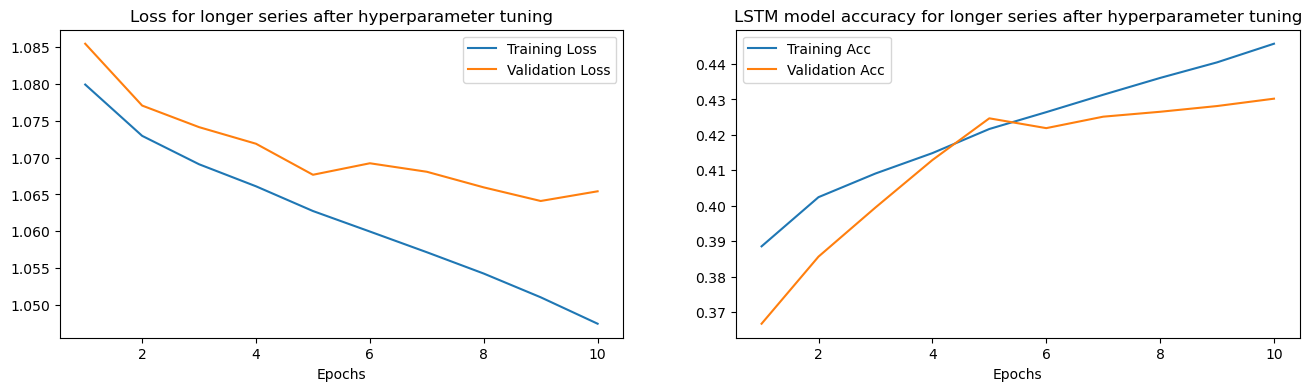

In [452]:
# Plotting the loss on the first subplot
hist_l = model_LSTM_long_fit.history
fig = plt.figure(figsize = (16, 4))
ax = fig.add_subplot(1, 2, 1)
plt.plot(range(1, num_epochs+1), hist_l['loss'], label='Training Loss')
plt.plot(range(1, num_epochs+1), hist_l['val_loss'], label='Validation Loss')
plt.legend()
ax.set_xlabel('Epochs')
ax.set_title('Loss for longer series after hyperparameter tuning');

# Plotting the accuracy on the second subplot
ax = fig.add_subplot(1, 2, 2)
plt.plot(range(1, num_epochs+1), hist_l['accuracy'], label='Training Acc')
plt.plot(range(1, num_epochs+1), hist_l['val_accuracy'], label='Validation Acc')
plt.legend()
ax.set_xlabel('Epochs')
ax.set_title('LSTM model accuracy for longer series after hyperparameter tuning')
plt.show()

In [453]:
print("Final training accuracy:", hist_l['accuracy'][-1])
print("Final validation accuracy:", hist_l['val_accuracy'][-1])

Final training accuracy: 0.44573840498924255
Final validation accuracy: 0.430221825838089


We notice that our accuracies here seem significantly worse than our accuracies in previous notebooks. This, again, is likely due to the fact that we were previously using incorrect data. However, we should keep in mind that what matters is our final precision results, and we should analyze our final test data to confirm how well our model did. For example, even with a test validation accuracy of 43%, much of that may be concentrated within Class 1, which we don't really care about. Furthermore, what matters to us is precision over recall, and our model may perform in one aspect than another.

In [454]:
# Evaluating the model against X_test and Y_test
model_LSTM_long.evaluate(X_test, Y_test)

149/149 ━━━━━━━━━━━━━━━━━━━━ 4s 24ms/step - accuracy: 0.4383 - loss: 1.0513


[1.0495628118515015, 0.4399999976158142]

Overall, we get a test accuracy of 44%, which at least implies our model generalizes alright, even if the percent itself isn't great. From now on, instead of training the model over and over again, we will simply load in the model itself and use that for our future tests.

In [486]:
# Reloading the model and running the test accuracy again to confirm it still works
model_LSTM_long_2 = load_model('model_LSTM_long_2025_03_24.keras', custom_objects={'loss_fn': loss_fn})
model_LSTM_long_2.evaluate(X_test, Y_test)

149/149 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - accuracy: 0.4383 - loss: 1.7772


[1.7163993120193481, 0.4399999976158142]

### Plotting a confusion matrix for the test predictions

In [487]:
# Getting Y_test_pred for the model
Y_test_pred = model_LSTM_long.predict(X_test)
Y_test_pred_perc = Y_test_pred.copy()
Y_test_pred = np.argmax(Y_test_pred, axis = 1)

# Getting the confusion matrix using Y_test and Y_test_pred
cf = confusion_matrix(
    Y_test,
    Y_test_pred
)

print('Generating the confusion matrix using confusion_matrix from '
  'sklearn.metrics:')
cf

149/149 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step
Generating the confusion matrix using confusion_matrix from sklearn.metrics:


array([[700, 277, 354],
       [457, 976, 385],
       [589, 598, 414]])

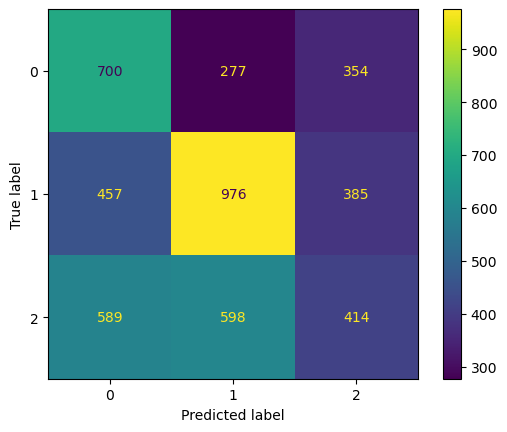

In [488]:
# Plotting the confusion matrix for the model
disp = ConfusionMatrixDisplay.from_predictions(
    y_true=Y_test,
    y_pred=Y_test_pred,
    labels=None
)

### Further analyses
We note that this confusion matrix looks pretty terrible, and we would not go in based on what this model outputs. However, it might be worthwhile to see the accuracies as we go through each day in the test data. Furthermore, we can also assign a threshold of 0.5 so that we would only predict a class of 0 or 2 if the softmax outputs are at least 0.5 for that respective class.

In [493]:
# Setting a prediction threshold of 0.5
pred_threshold = 0.5

# Creating a loop that loops through 10 days of data and predicts once for each day
for i in range(10):
    
    # Setting a range for the test data
    start_range = i * unique_tickers
    end_range = (i + 1) * unique_tickers

    # Getting the one-day predictions
    Y_test_pred_one_day = model_LSTM_long.predict(X_test[start_range:end_range])
    pred_class_one_day = np.where(Y_test_pred_one_day[:, 0] > pred_threshold, 0,
                                  np.where(Y_test_pred_one_day[:, 2] > pred_threshold, 2, 1))

    cf_one_day = confusion_matrix(
        Y_test[start_range:end_range],
        pred_class_one_day
    )
    
    print(cf_one_day)

15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
[[ 28 154   2]
 [ 12 165   2]
 [ 10  96   6]]
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
[[ 37 398   7]
 [  1  19   1]
 [  2   8   2]]
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
[[ 10 253  20]
 [  5 112   6]
 [  5  59   5]]
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
[[  7  12   4]
 [ 16  39   3]
 [196 185  13]]
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
[[  0  36   5]
 [  1 182  32]
 [  3 170  46]]
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
[[  1  13   0]
 [  1 122   1]
 [  0 327  10]]
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
[[  2  13   0]
 [ 12 199   1]
 [ 18 228   2]]
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
[[ 12  72   0]
 [ 16 305   0]
 [  5  65   0]]
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
[[ 16 119   1]
 [ 20 255   5]
 [  7  49   3]]
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
[[  2 105   2]
 [  3 280   2]
 [  2  77   2]]


These results are quite telling, as we notice that only the very first day outputs decent results, at least with our threshold of 0.5. This clearly might just be a fluke, so the next test to perform would be to retrain the model with the new piece of data, and re-predict the next day. However, because this process will take ~10 hours (as it took ~1 hour to run the model above), we will experiment with simpler models first to see if we can get better results.

## LSTM Classification (all stocks, longer series, smaller test and validation data sizes, simpler model)
We will try using a simpler model of just 1 LSTM layer and 1 dropout layer (with a rate of 0.3).

### Generating X continuous series sequences, Y continuous labels, and splitting data into train and test sets

In [494]:
# Creating sequences for LSTM model
seq_length = 35
group_col = 'Ticker'
target_col = 'Close_Open_Diff_Ternary'
drop_cols = ['Date_col', 'Close_Open_Diff_Perc']

X_data_smaller, Y_data_smaller = create_sequences_grouped(data_smaller, seq_length, group_col, target_col, drop_cols)

In [495]:
# Confirming shapes
print('Shape of X_data_smaller:', X_data_smaller.shape)
print('Shape of Y_data_smaller:', Y_data_smaller.shape, '\n')

# Confirming that we should have the correct number of sequences in X_data_smaller
unique_tickers = data_smaller['Ticker'].nunique()
unique_dates = data_smaller['Date_col'].nunique()
expected_num_sequences = unique_tickers * (unique_dates - seq_length + 1)

print('Number of unique tickers in data_smaller:', unique_tickers)
print('Number of unique dates in data_smaller:', unique_dates)
print('Chosen sequence length:', seq_length)
print('Number of sequences assuming the above seq_length:', unique_dates - seq_length + 1)
print('(We need to add 1 to the end to account for either the beginning or the end. For example, if we had 12 observations with a window')
print('of 5, we would need 12 - 5 + 1 = 8 sequences, the first one being having indices from [0:5], and the last from [7:12].)\n')
print('Total number of data sequences expected:', expected_num_sequences)
print('Total number of data sequences achieved:', X_data_smaller.shape[0])

Shape of X_data_smaller: (437475, 35, 32)
Shape of Y_data_smaller: (437475,) 

Number of unique tickers in data_smaller: 475
Number of unique dates in data_smaller: 955
Chosen sequence length: 35
Number of sequences assuming the above seq_length: 921
(We need to add 1 to the end to account for either the beginning or the end. For example, if we had 12 observations with a window
of 5, we would need 12 - 5 + 1 = 8 sequences, the first one being having indices from [0:5], and the last from [7:12].)

Total number of data sequences expected: 437475
Total number of data sequences achieved: 437475


In [496]:
# Getting the number of sequences per ticker (same calculation as above, but now defined in a variable)
num_sequences_per_ticker = unique_dates - seq_length + 1

# Splitting the data into train and test sets
num_train_seq_int = int(0.99 * num_sequences_per_ticker)  # Need int split to separate correct number of sequences for train and test data
train_size = num_train_seq_int * unique_tickers  # Another way to think about it: regardless of the num_train_seq_int value, we need to go
# ^up by the number of tickers (e.g., 400) at an integer amount each time
X_train = X_data_smaller[:train_size]
Y_train = Y_data_smaller[:train_size]
X_test = X_data_smaller[train_size:]
Y_test = Y_data_smaller[train_size:]

# Confirming shapes
print('Shape of X_train:', X_train.shape)
print('Shape of Y_train:', Y_train.shape)
print('Shape of X_test:', X_test.shape)
print('Shape of Y_test:', Y_test.shape, '\n')

# Confirming number of dates
print('Number of dates in X_train:', num_train_seq_int)
print('Number of dates in X_test:', num_sequences_per_ticker - num_train_seq_int)

Shape of X_train: (432725, 35, 32)
Shape of Y_train: (432725,)
Shape of X_test: (4750, 35, 32)
Shape of Y_test: (4750,) 

Number of dates in X_train: 911
Number of dates in X_test: 10


### Building and compiling LSTM model

In [505]:
# Defining a function to create and compile tf model
def build_LSTM_model_simple(seq_length,
                     num_features,
                     n_classes,
                     LSTM_units=256,
                     learning_rate=0.01,
                     optimizer='SGD',
                     metric='accuracy'):

    # Resetting tf for consistent results
    tf.keras.backend.clear_session()
    np.random.seed(0)
    tf.random.set_seed(0)
    
    # Building a model using tf Sequential
    model = tf.keras.Sequential()

    # Input layer
    model.add(tf.keras.Input(shape=(seq_length, num_features), name='Input'))
    
    # LSTM layer
    model.add(LSTM(units=LSTM_units, return_sequences=False, name='LSTM'))

    # Dropout layer
    model.add(Dropout(0.3, name='Dropout'))

    # Output layer
    model.add(tf.keras.layers.Dense(
      units = n_classes,
      activation = 'softmax',
      name = 'Output'
    ))
    
    # Setting optimizer and specific learning rate
    optimizer_class = getattr(tf.keras.optimizers, optimizer)
    optimizer_true = optimizer_class(learning_rate=learning_rate)
    
    # Compiling the model
    model.compile(
      optimizer = optimizer_true,
      loss = tf.keras.losses.SparseCategoricalCrossentropy(),
      metrics = [metric]
    )
    
    return model

### Hyperparameter-tuned LSTM model (256 LSTM units)
We'll be using training with 10 epochs and a batch size of 256, along with keeping our learning rate at 0.0001.

In [506]:
tf.random.set_seed(1234)
np.random.seed(1234)

# Setting hyperparameters
seq_length = X_train.shape[1]
num_features = X_train.shape[2]
n_classes = 3
LSTM_units = 256
learning_rate = 0.0001
optimizer = 'Adam'
metric = 'accuracy'
num_epochs = 10
batch_size = 256

# Building and compiling the model
model_LSTM_simple_256 = build_LSTM_model_simple(seq_length=seq_length,
                                      num_features=num_features,
                                      n_classes=n_classes,
                                      LSTM_units=LSTM_units,
                                      learning_rate=learning_rate,
                                      optimizer=optimizer,
                                      metric=metric)
print(model_LSTM_simple_256.summary())

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ LSTM (LSTM)                     │ (None, 256)            │       295,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output (Dense)                  │ (None, 3)              │           771 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 296,707 (1.13 MB)

 Trainable params: 296,707 (1.13 MB)

 Non-trainable params: 0 (0.00 B)

None


In [507]:
# Training the model using the training dataset
model_LSTM_simple_256_fit = model_LSTM_simple_256.fit(
    x = X_train,
    y = Y_train,
    validation_split = 0.01,  # Validation split also 0.01 just like the test split
    epochs = num_epochs,
    batch_size = batch_size,
    verbose = 1
)

Epoch 1/10
1674/1674 ━━━━━━━━━━━━━━━━━━━━ 151s 90ms/step - accuracy: 0.3803 - loss: 1.0844 - val_accuracy: 0.3681 - val_loss: 1.0848
Epoch 2/10
1674/1674 ━━━━━━━━━━━━━━━━━━━━ 145s 87ms/step - accuracy: 0.4001 - loss: 1.0739 - val_accuracy: 0.3877 - val_loss: 1.0797
Epoch 3/10
1674/1674 ━━━━━━━━━━━━━━━━━━━━ 144s 86ms/step - accuracy: 0.4063 - loss: 1.0706 - val_accuracy: 0.3953 - val_loss: 1.0751
Epoch 4/10
1674/1674 ━━━━━━━━━━━━━━━━━━━━ 147s 88ms/step - accuracy: 0.4109 - loss: 1.0687 - val_accuracy: 0.3986 - val_loss: 1.0739
Epoch 5/10
1674/1674 ━━━━━━━━━━━━━━━━━━━━ 147s 88ms/step - accuracy: 0.4144 - loss: 1.0670 - val_accuracy: 0.4080 - val_loss: 1.0721
Epoch 6/10
1674/1674 ━━━━━━━━━━━━━━━━━━━━ 146s 87ms/step - accuracy: 0.4164 - loss: 1.0655 - val_accuracy: 0.4175 - val_loss: 1.0690
Epoch 7/10
1674/1674 ━━━━━━━━━━━━━━━━━━━━ 147s 88ms/step - accuracy: 0.4204 - loss: 1.0641 - val_accuracy: 0.4161 - val_loss: 1.0683
Epoch 8/10
1674/1674 ━━━━━━━━━━━━━━━━━━━━ 145s 87ms/step - accuracy: 

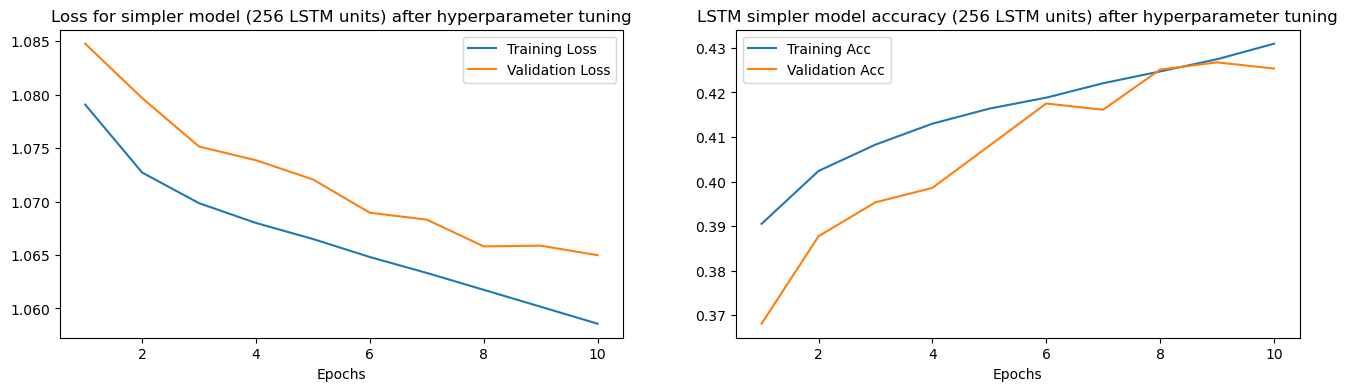

In [508]:
# Plotting the loss on the first subplot
hist_s_256 = model_LSTM_simple_256_fit.history
fig = plt.figure(figsize = (16, 4))
ax = fig.add_subplot(1, 2, 1)
plt.plot(range(1, num_epochs+1), hist_s_256['loss'], label='Training Loss')
plt.plot(range(1, num_epochs+1), hist_s_256['val_loss'], label='Validation Loss')
plt.legend()
ax.set_xlabel('Epochs')
ax.set_title('Loss for simpler model (256 LSTM units) after hyperparameter tuning');

# Plotting the accuracy on the second subplot
ax = fig.add_subplot(1, 2, 2)
plt.plot(range(1, num_epochs+1), hist_s_256['accuracy'], label='Training Acc')
plt.plot(range(1, num_epochs+1), hist_s_256['val_accuracy'], label='Validation Acc')
plt.legend()
ax.set_xlabel('Epochs')
ax.set_title('LSTM simpler model accuracy (256 LSTM units) after hyperparameter tuning')
plt.show()

In [509]:
print("Final training accuracy:", hist_s_256['accuracy'][-1])
print("Final validation accuracy:", hist_s_256['val_accuracy'][-1])

Final training accuracy: 0.43094372749328613
Final validation accuracy: 0.4253696799278259


This is very interesting - we see that this simpler model actually has comparable training and validation accuracies to the more complex model we used previously. Furthermore, the validation accuracies might be able to get even better with more training (if we wanted to continue doing so). One reason this might be the case is that the model isn't picking up on as much noise, so it's better able to evaluate new test cases.

In [510]:
# Evaluating the model against X_test and Y_test
model_LSTM_simple_256.evaluate(X_test, Y_test)

149/149 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.4651 - loss: 1.0459


[1.0455882549285889, 0.464631587266922]

Overall, we get a test accuracy of 46%, which actually surpasses the test accuracy from before. This provides more evidence to simply the model even further, perhaps down to 128 LSTM units. Either way, we can plot the confusion matrix to better visualize our results.

#### Plotting a confusion matrix for the test predictions

In [511]:
# Getting Y_test_pred for the model
Y_test_pred = model_LSTM_simple_256.predict(X_test)
Y_test_pred_perc = Y_test_pred.copy()
Y_test_pred = np.argmax(Y_test_pred, axis = 1)

# Getting the confusion matrix using Y_test and Y_test_pred
cf = confusion_matrix(
    Y_test,
    Y_test_pred
)

print('Generating the confusion matrix using confusion_matrix from '
  'sklearn.metrics:')
cf

149/149 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step
Generating the confusion matrix using confusion_matrix from sklearn.metrics:


array([[ 767,  282,  282],
       [ 471, 1032,  315],
       [ 556,  637,  408]])

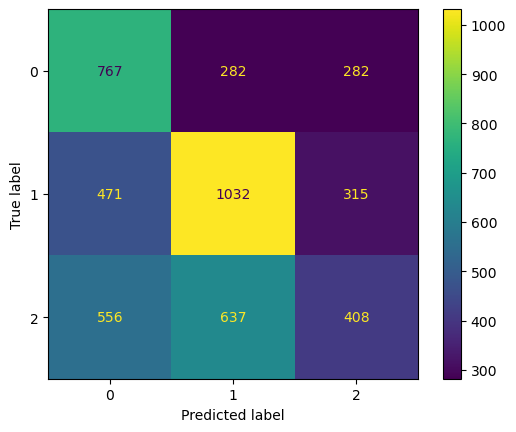

In [512]:
# Plotting the confusion matrix for the model
disp = ConfusionMatrixDisplay.from_predictions(
    y_true=Y_test,
    y_pred=Y_test_pred,
    labels=None
)

We see that in the confusion matrix that our accuracies are indeed comparable to before. Once again, we can analyze individual day metrics to see how well our model did for each day.

#### Further analyses with prediction threshold

In [524]:
# Setting a prediction threshold of 0.5
pred_threshold = 0.5

# Creating a loop that loops through 10 days of data and predicts once for each day
for i in range(10):
    
    # Setting a range for the test data
    start_range = i * unique_tickers
    end_range = (i + 1) * unique_tickers

    # Getting the one-day predictions
    Y_test_pred_one_day = model_LSTM_simple_256.predict(X_test[start_range:end_range])
    pred_class_one_day = np.where(Y_test_pred_one_day[:, 0] > pred_threshold, 0,
                                  np.where(Y_test_pred_one_day[:, 2] > pred_threshold, 2, 1))

    cf_one_day = confusion_matrix(
        Y_test[start_range:end_range],
        pred_class_one_day
    )
    
    print(cf_one_day)

15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
[[ 16 167   1]
 [  4 174   1]
 [  4 105   3]]
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
[[ 22 414   6]
 [  1  20   0]
 [  2  10   0]]
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
[[  9 267   7]
 [  2 119   2]
 [  4  59   6]]
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
[[  7  10   6]
 [ 19  35   4]
 [157 217  20]]
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
[[  0  40   1]
 [  1 209   5]
 [  1 210   8]]
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
[[  2  12   0]
 [  1 123   0]
 [  0 337   0]]
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
[[  1  13   1]
 [  2 210   0]
 [  1 247   0]]
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
[[  3  80   1]
 [  7 314   0]
 [  1  69   0]]
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
[[  7 129   0]
 [  8 269   3]
 [  3  56   0]]
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
[[  4 105   0]
 [  5 280   0]
 [  1  80   0]]


And once again, we notice that the first day significantly outperforms all other days. The 0.5 threshold may have been a bit too much, but this lends more evidence to the idea that this model can only predict one day ahead.

### Hyperparameter-tuned LSTM model (128 LSTM units)
We'll be using training with 10 epochs and a batch size of 256, along with keeping our learning rate at 0.0001.

In [513]:
tf.random.set_seed(1234)
np.random.seed(1234)

# Setting hyperparameters
seq_length = X_train.shape[1]
num_features = X_train.shape[2]
n_classes = 3
LSTM_units = 128
learning_rate = 0.0001
optimizer = 'Adam'
metric = 'accuracy'
num_epochs = 10
batch_size = 256

# Building and compiling the model
model_LSTM_simple_128 = build_LSTM_model_simple(seq_length=seq_length,
                                      num_features=num_features,
                                      n_classes=n_classes,
                                      LSTM_units=LSTM_units,
                                      learning_rate=learning_rate,
                                      optimizer=optimizer,
                                      metric=metric)
print(model_LSTM_simple_128.summary())

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ LSTM (LSTM)                     │ (None, 128)            │        82,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output (Dense)                  │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 82,819 (323.51 KB)

 Trainable params: 82,819 (323.51 KB)

 Non-trainable params: 0 (0.00 B)

None


In [514]:
# Training the model using the training dataset
model_LSTM_simple_128_fit = model_LSTM_simple_128.fit(
    x = X_train,
    y = Y_train,
    validation_split = 0.01,  # Validation split also 0.01 just like the test split
    epochs = num_epochs, 
    batch_size = batch_size,
    verbose = 1
)

Epoch 1/10
1674/1674 ━━━━━━━━━━━━━━━━━━━━ 101s 60ms/step - accuracy: 0.3790 - loss: 1.0866 - val_accuracy: 0.3773 - val_loss: 1.0828
Epoch 2/10
1674/1674 ━━━━━━━━━━━━━━━━━━━━ 103s 61ms/step - accuracy: 0.3958 - loss: 1.0749 - val_accuracy: 0.3926 - val_loss: 1.0778
Epoch 3/10
1674/1674 ━━━━━━━━━━━━━━━━━━━━ 104s 62ms/step - accuracy: 0.4035 - loss: 1.0718 - val_accuracy: 0.4071 - val_loss: 1.0734
Epoch 4/10
1674/1674 ━━━━━━━━━━━━━━━━━━━━ 103s 62ms/step - accuracy: 0.4077 - loss: 1.0699 - val_accuracy: 0.4067 - val_loss: 1.0714
Epoch 5/10
1674/1674 ━━━━━━━━━━━━━━━━━━━━ 104s 62ms/step - accuracy: 0.4106 - loss: 1.0684 - val_accuracy: 0.4108 - val_loss: 1.0715
Epoch 6/10
1674/1674 ━━━━━━━━━━━━━━━━━━━━ 104s 62ms/step - accuracy: 0.4127 - loss: 1.0670 - val_accuracy: 0.4134 - val_loss: 1.0704
Epoch 7/10
1674/1674 ━━━━━━━━━━━━━━━━━━━━ 105s 63ms/step - accuracy: 0.4165 - loss: 1.0652 - val_accuracy: 0.4154 - val_loss: 1.0696
Epoch 8/10
1674/1674 ━━━━━━━━━━━━━━━━━━━━ 105s 63ms/step - accuracy: 

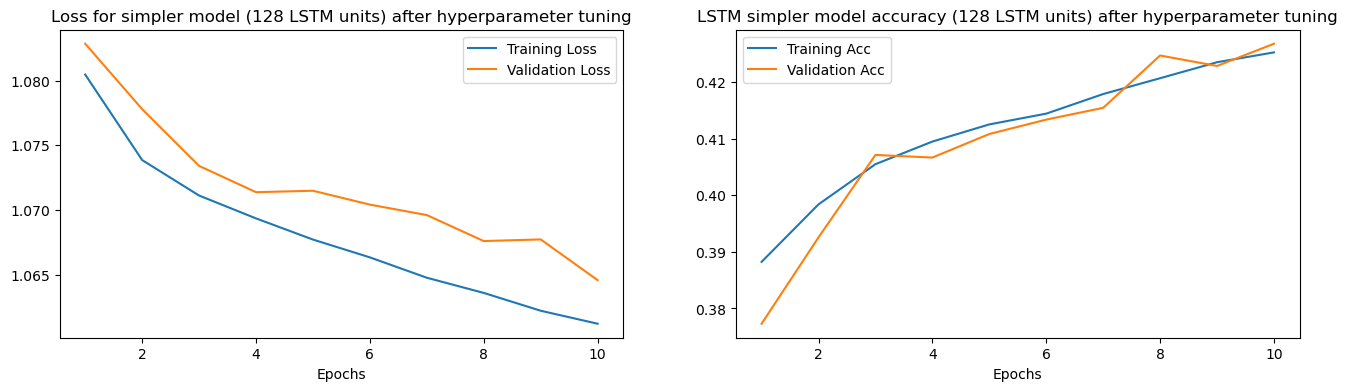

In [515]:
# Plotting the loss on the first subplot
hist_s_128 = model_LSTM_simple_128_fit.history
fig = plt.figure(figsize = (16, 4))
ax = fig.add_subplot(1, 2, 1)
plt.plot(range(1, num_epochs+1), hist_s_128['loss'], label='Training Loss')
plt.plot(range(1, num_epochs+1), hist_s_128['val_loss'], label='Validation Loss')
plt.legend()
ax.set_xlabel('Epochs')
ax.set_title('Loss for simpler model (128 LSTM units) after hyperparameter tuning');

# Plotting the accuracy on the second subplot
ax = fig.add_subplot(1, 2, 2)
plt.plot(range(1, num_epochs+1), hist_s_128['accuracy'], label='Training Acc')
plt.plot(range(1, num_epochs+1), hist_s_128['val_accuracy'], label='Validation Acc')
plt.legend()
ax.set_xlabel('Epochs')
ax.set_title('LSTM simpler model accuracy (128 LSTM units) after hyperparameter tuning')
plt.show()

In [516]:
print("Final training accuracy:", hist_s_128['accuracy'][-1])
print("Final validation accuracy:", hist_s_128['val_accuracy'][-1])

Final training accuracy: 0.4252270758152008
Final validation accuracy: 0.42675599455833435


Once again, we see pretty comparable training and validation accuracies compared to the previous tests. Furthermore, this model only took ~17 minutes to run, dramatically saving on compute time. We can check the test accuracy as well next.


In [517]:
# Evaluating the model against X_test and Y_test
model_LSTM_simple_128.evaluate(X_test, Y_test)

149/149 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.4560 - loss: 1.0503


[1.046712040901184, 0.4618947505950928]

And we once again get a test accuracy of 46%. This perhaps provides evidence to simplify the model even further, or perhaps chance the learning rate, epochs, or batch size.

#### Plotting a confusion matrix for the test predictions

In [518]:
# Getting Y_test_pred for the model
Y_test_pred = model_LSTM_simple_128.predict(X_test)
Y_test_pred_perc = Y_test_pred.copy()
Y_test_pred = np.argmax(Y_test_pred, axis = 1)

# Getting the confusion matrix using Y_test and Y_test_pred
cf = confusion_matrix(
    Y_test,
    Y_test_pred
)

print('Generating the confusion matrix using confusion_matrix from '
  'sklearn.metrics:')
cf

149/149 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
Generating the confusion matrix using confusion_matrix from sklearn.metrics:


array([[ 730,  325,  276],
       [ 450, 1077,  291],
       [ 547,  667,  387]])

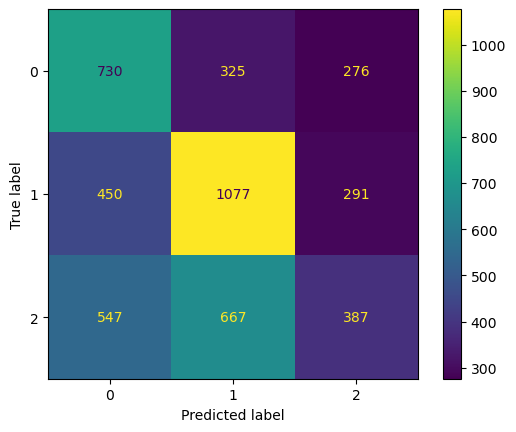

In [519]:
# Plotting the confusion matrix for the model
disp = ConfusionMatrixDisplay.from_predictions(
    y_true=Y_test,
    y_pred=Y_test_pred,
    labels=None
)

We see that in the confusion matrix that our accuracies are still comparable to before. Once again, we can analyze individual day metrics to see how well our model did for each day.

#### Further analyses with prediction threshold

In [531]:
# Setting a prediction threshold of 0.5
pred_threshold = 0.5

# Creating a loop that loops through 10 days of data and predicts once for each day
for i in range(10):
    
    # Setting a range for the test data
    start_range = i * unique_tickers
    end_range = (i + 1) * unique_tickers

    # Getting the one-day predictions
    Y_test_pred_one_day = model_LSTM_simple_128.predict(X_test[start_range:end_range])
    pred_class_one_day = np.where(Y_test_pred_one_day[:, 0] > pred_threshold, 0,
                                  np.where(Y_test_pred_one_day[:, 2] > pred_threshold, 2, 1))

    cf_one_day = confusion_matrix(
        Y_test[start_range:end_range],
        pred_class_one_day
    )
    
    print(cf_one_day)

15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
[[ 11 171   2]
 [  3 176   0]
 [  2 108   2]]
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
[[ 12 427   3]
 [  1  20   0]
 [  1  11   0]]
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
[[  5 273   5]
 [  1 122   0]
 [  3  61   5]]
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
[[  6  13   4]
 [ 19  36   3]
 [151 229  14]]
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
[[  0  41   0]
 [  0 213   2]
 [  0 216   3]]
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
[[  1  13   0]
 [  1 123   0]
 [  0 337   0]]
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
[[  1  14   0]
 [  1 211   0]
 [  1 247   0]]
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
[[  1  83   0]
 [  4 317   0]
 [  1  69   0]]
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
[[  2 134   0]
 [  6 272   2]
 [  3  56   0]]
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
[[  2 107   0]
 [  0 285   0]
 [  1  80   0]]


Unfortunately, this is where our model falters a bit. While our test accuracies are good overall, even the first-day test accuracy isn't perfect (at least for class 2). This might mean we should go back to the simple model with 256 LSTM units, though it might be worth tuning these models some more.

### Hyperparameter-tuned LSTM model (128 LSTM units, 128 batch size, 0.001 learning rate)
We'll be using training with 10 epochs and a batch size of 128, along with increasing our learning rate to 0.001.

In [532]:
tf.random.set_seed(1234)
np.random.seed(1234)

# Setting hyperparameters
seq_length = X_train.shape[1]
num_features = X_train.shape[2]
n_classes = 3
LSTM_units = 128
learning_rate = 0.001
optimizer = 'Adam'
metric = 'accuracy'
num_epochs = 10
batch_size = 128

# Building and compiling the model
model_LSTM_simple_128_1 = build_LSTM_model_simple(seq_length=seq_length,
                                      num_features=num_features,
                                      n_classes=n_classes,
                                      LSTM_units=LSTM_units,
                                      learning_rate=learning_rate,
                                      optimizer=optimizer,
                                      metric=metric)
print(model_LSTM_simple_128_1.summary())

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ LSTM (LSTM)                     │ (None, 128)            │        82,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output (Dense)                  │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 82,819 (323.51 KB)

 Trainable params: 82,819 (323.51 KB)

 Non-trainable params: 0 (0.00 B)

None


In [533]:
# Training the model using the training dataset
model_LSTM_simple_128_1_fit = model_LSTM_simple_128_1.fit(
    x = X_train,
    y = Y_train,
    validation_split = 0.01,  # Validation split also 0.01 just like the test split
    epochs = num_epochs, 
    batch_size = batch_size,
    verbose = 1
)

Epoch 1/10
3347/3347 ━━━━━━━━━━━━━━━━━━━━ 108s 32ms/step - accuracy: 0.3990 - loss: 1.0755 - val_accuracy: 0.4071 - val_loss: 1.0739
Epoch 2/10
3347/3347 ━━━━━━━━━━━━━━━━━━━━ 108s 32ms/step - accuracy: 0.4246 - loss: 1.0615 - val_accuracy: 0.4150 - val_loss: 1.0692
Epoch 3/10
3347/3347 ━━━━━━━━━━━━━━━━━━━━ 111s 33ms/step - accuracy: 0.4331 - loss: 1.0562 - val_accuracy: 0.4265 - val_loss: 1.0644
Epoch 4/10
3347/3347 ━━━━━━━━━━━━━━━━━━━━ 102s 30ms/step - accuracy: 0.4478 - loss: 1.0445 - val_accuracy: 0.4196 - val_loss: 1.0657
Epoch 5/10
3347/3347 ━━━━━━━━━━━━━━━━━━━━ 111s 33ms/step - accuracy: 0.4693 - loss: 1.0226 - val_accuracy: 0.4124 - val_loss: 1.0697
Epoch 6/10
3347/3347 ━━━━━━━━━━━━━━━━━━━━ 104s 31ms/step - accuracy: 0.4826 - loss: 1.0064 - val_accuracy: 0.4161 - val_loss: 1.0690
Epoch 7/10
3347/3347 ━━━━━━━━━━━━━━━━━━━━ 113s 34ms/step - accuracy: 0.4919 - loss: 0.9950 - val_accuracy: 0.4212 - val_loss: 1.0718
Epoch 8/10
3347/3347 ━━━━━━━━━━━━━━━━━━━━ 110s 33ms/step - accuracy: 

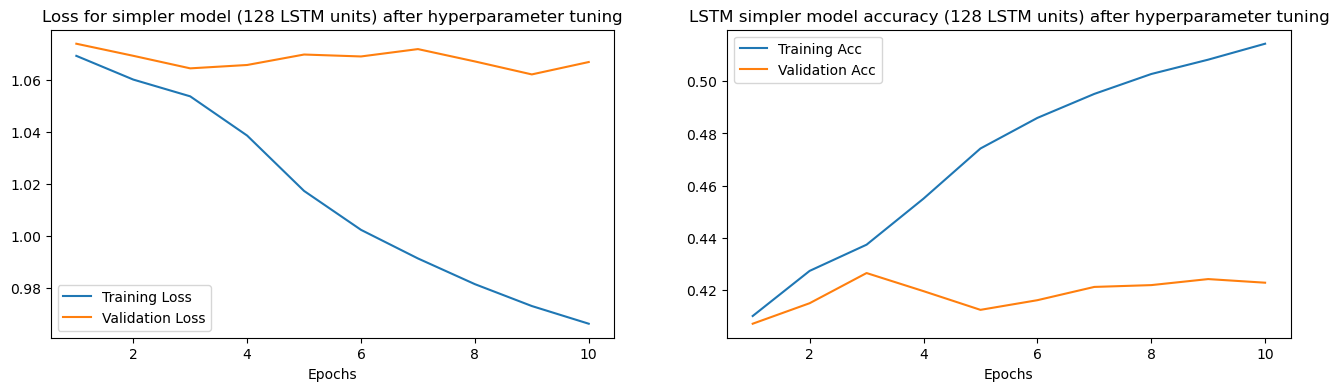

In [534]:
# Plotting the loss on the first subplot
hist_s_128_1 = model_LSTM_simple_128_1_fit.history
fig = plt.figure(figsize = (16, 4))
ax = fig.add_subplot(1, 2, 1)
plt.plot(range(1, num_epochs+1), hist_s_128_1['loss'], label='Training Loss')
plt.plot(range(1, num_epochs+1), hist_s_128_1['val_loss'], label='Validation Loss')
plt.legend()
ax.set_xlabel('Epochs')
ax.set_title('Loss for simpler model (128 LSTM units) after hyperparameter tuning');

# Plotting the accuracy on the second subplot
ax = fig.add_subplot(1, 2, 2)
plt.plot(range(1, num_epochs+1), hist_s_128_1['accuracy'], label='Training Acc')
plt.plot(range(1, num_epochs+1), hist_s_128_1['val_accuracy'], label='Validation Acc')
plt.legend()
ax.set_xlabel('Epochs')
ax.set_title('LSTM simpler model accuracy (128 LSTM units) after hyperparameter tuning')
plt.show()

In [535]:
print("Final training accuracy:", hist_s_128_1['accuracy'][-1])
print("Final validation accuracy:", hist_s_128_1['val_accuracy'][-1])

Final training accuracy: 0.5143593549728394
Final validation accuracy: 0.4228281080722809


While our training accuracy was certainly higher, our validation accuracy remained roughly the same. It appears that we hit a plateau relatively quickly, so dropping the learning rate would likely help with that.

In [536]:
# Evaluating the model against X_test and Y_test
model_LSTM_simple_128_1.evaluate(X_test, Y_test)

149/149 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.4203 - loss: 1.0730


[1.0745879411697388, 0.4263157844543457]

As expected, our test accuracy took a hit, again due to the higher learning rate and fewer epochs. We can confirm our observations with a confusion matrix.

#### Plotting a confusion matrix for the test predictions

In [537]:
# Getting Y_test_pred for the model
Y_test_pred = model_LSTM_simple_128_1.predict(X_test)
Y_test_pred_perc = Y_test_pred.copy()
Y_test_pred = np.argmax(Y_test_pred, axis = 1)

# Getting the confusion matrix using Y_test and Y_test_pred
cf = confusion_matrix(
    Y_test,
    Y_test_pred
)

print('Generating the confusion matrix using confusion_matrix from '
  'sklearn.metrics:')
cf

149/149 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
Generating the confusion matrix using confusion_matrix from sklearn.metrics:


array([[647, 286, 398],
       [423, 968, 427],
       [591, 600, 410]])

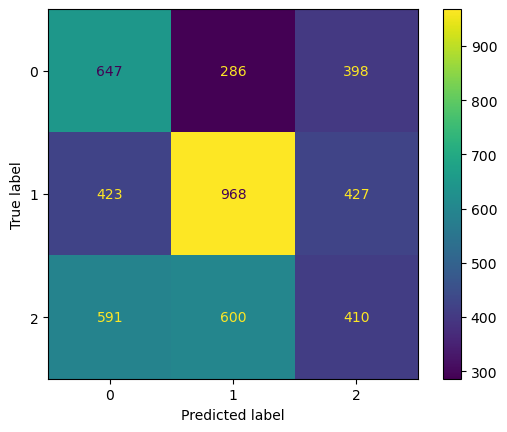

In [538]:
# Plotting the confusion matrix for the model
disp = ConfusionMatrixDisplay.from_predictions(
    y_true=Y_test,
    y_pred=Y_test_pred,
    labels=None
)

And we do indeed confirm our results, with this model not performing as well as the previous ones.

#### Further analyses with prediction threshold

In [539]:
# Setting a prediction threshold of 0.5
pred_threshold = 0.5

# Creating a loop that loops through 10 days of data and predicts once for each day
for i in range(10):
    
    # Setting a range for the test data
    start_range = i * unique_tickers
    end_range = (i + 1) * unique_tickers

    # Getting the one-day predictions
    Y_test_pred_one_day = model_LSTM_simple_128_1.predict(X_test[start_range:end_range])
    pred_class_one_day = np.where(Y_test_pred_one_day[:, 0] > pred_threshold, 0,
                                  np.where(Y_test_pred_one_day[:, 2] > pred_threshold, 2, 1))

    cf_one_day = confusion_matrix(
        Y_test[start_range:end_range],
        pred_class_one_day
    )
    
    print(cf_one_day)

15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
[[ 36 139   9]
 [ 13 156  10]
 [ 11  91  10]]
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
[[ 67 348  27]
 [  1  17   3]
 [  3   9   0]]
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
[[ 50 215  18]
 [ 16 101   6]
 [ 11  55   3]]
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
[[  8  10   5]
 [ 23  33   2]
 [198 177  19]]
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
[[  1  31   9]
 [  6 120  89]
 [  5 125  89]]
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
[[  2  11   1]
 [  2 120   2]
 [  2 326   9]]
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
[[  2  12   1]
 [ 25 183   4]
 [ 42 203   3]]
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
[[ 12  70   2]
 [ 22 290   9]
 [  7  60   3]]
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
[[  8 121   7]
 [ 16 246  18]
 [  5  47   7]]
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
[[  8  98   3]
 [ 11 263  11]
 [  1  74   6]]


We also don't get great results even on the first test day. However, this brings up another point: we should dramatically decrease our validation test size, as well as increasing our test *range*. Specifically, we can use our sliding window model from before, but this time running our simpler models with this correct dataset and focusing only on our precisions for Class 0 and Class 2.

# LSTM Model Testing with Sliding Windows and Smaller Val/Test Sizes
We'll be trying 2 techniques with these sliding windows:
1. Implementing incremental fine-tuning (i.e., continued training), where we have a base model that we train, and then slowly improve it using the new data from each sliding window.
2. Re-training the model with the same training range each time we add new data into the model; this will take much longer, but we might get more consistent results and avoid the problem of overfitting.

## Function for Creating Sequences for LSTM Model
This is used to create our X and Y sequences in the LSTM model, and it's the same function as before.

***NOTE: In previous notebooks, we did not have the "NEW ADDITION" code at the bottom, which means that our numpy arrays were sorted first by ticker, and then by date, rather than the other way around. What this means for all of our previous experiments involving this function is that our test dataset was essentially just the last few dates of the last (few) tickers (e.g., 12/15/24 - 12/31/24 for just ZTS). This is obviously not how we want our predictions to go, and we want to be able to predict ALL tickers, not just the last one. Therefore, our results previously could be considered null and void. However, because we were able to get decent validation accuracies, and because we still trained on roughly the same data, perhaps we will still get similar results. We will re-run the model and re-test our data to see if this is truly the case.**

In [540]:
# Function for creating sequences for LSTM model
def create_sequences_grouped(df, seq_length, group_col, target_col, drop_cols):
    """Create LSTM sequences separately for each unique ticker in the dataset."""
    X, Y = [], []
    num_tickers = df['Ticker'].nunique()
    
    # Group data by unique time series identifier (i.e., 'Ticker')
    grouped = df.groupby(group_col)
    
    for _, group in grouped:
        # Sorting by Date_col and removing the 'Ticker' column and dropped columns
        group = group.sort_values(by='Date_col')
        group = group.drop(columns=drop_cols)
        group = group.drop(columns=[group_col])

        # Getting feature and label columns
        feature_cols = group.drop(columns=[target_col]).columns
        feature_data = group[feature_cols].values
        labels = group[target_col].values
        
        # Creating sequences for this group only
        for i in range(len(group) - seq_length + 1):
            X.append(feature_data[i:i+seq_length])  # Collecting seq_length time steps
            Y.append(labels[i+seq_length-1])   # Target label is the most recent time step

    # Converting dtypes to the correct dtype
    X = np.array(X)
    X = X.astype(np.float32)
    Y = np.array(Y)
    Y = Y.astype(np.int32)

    # NEW ADDITION: Correctly re-ordering data first by the date, and THEN by the ticker
    indices_by_date_then_ticker = np.arange(X.shape[0]).reshape((num_tickers, -1)).flatten('F')
    X = X[indices_by_date_then_ticker]
    Y = Y[indices_by_date_then_ticker]
    
    return X, Y

## LSTM Classification (even longer series, 796/3/1 window, sliding simpler model)
Instead of a sequence length of 35, we will try a length of 50, and we'll have our initial/sliding training window be 796 dates, with 3 dates of validation data and 1 for test.

### Generating X continuous series sequences, Y continuous labels, and splitting data into train and test sets

In [541]:
# Creating sequences for LSTM model
seq_length = 50
group_col = 'Ticker'
target_col = 'Close_Open_Diff_Ternary'
drop_cols = ['Date_col', 'Close_Open_Diff_Perc']

X_data_smaller, Y_data_smaller = create_sequences_grouped(data_smaller, seq_length, group_col, target_col, drop_cols)

In [551]:
# Confirming shapes
print('Shape of X_data_smaller:', X_data_smaller.shape)
print('Shape of Y_data_smaller:', Y_data_smaller.shape, '\n')

# Confirming that we should have the correct number of sequences in X_data_smaller
unique_tickers = data_smaller['Ticker'].nunique()
unique_dates = data_smaller['Date_col'].nunique()
expected_num_sequences = unique_tickers * (unique_dates - seq_length + 1)

print('Number of unique tickers in data_smaller:', unique_tickers)
print('Number of unique dates in data_smaller:', unique_dates)
print('Chosen sequence length:', seq_length)
print('Number of sequences assuming the above seq_length:', unique_dates - seq_length + 1)
print('(We need to add 1 to the end to account for either the beginning or the end. For example, if we had 12 observations with a window')
print('of 5, we would need 12 - 5 + 1 = 8 sequences, the first one being having indices from [0:5], and the last from [7:12].)\n')
print('Total number of data sequences expected:', expected_num_sequences)
print('Total number of data sequences achieved:', X_data_smaller.shape[0])

Shape of X_data_smaller: (430350, 50, 32)
Shape of Y_data_smaller: (430350,) 

Number of unique tickers in data_smaller: 475
Number of unique dates in data_smaller: 955
Chosen sequence length: 50
Number of sequences assuming the above seq_length: 906
(We need to add 1 to the end to account for either the beginning or the end. For example, if we had 12 observations with a window
of 5, we would need 12 - 5 + 1 = 8 sequences, the first one being having indices from [0:5], and the last from [7:12].)

Total number of data sequences expected: 430350
Total number of data sequences achieved: 430350


### Defining function for splitting sequence data into train, val, and test splits

In [552]:
# Defining function to split sequence data into train, val, test splits with split size (in terms of # of days)
def train_val_test_seq_split(X_window, Y_window, num_tickers, train_size, val_size, test_size):
    X_data = X_window.copy()
    Y_data = Y_window.copy()

    if (X_data.shape[0]/num_tickers) != (train_size + val_size + test_size):
        print("Train + val + test sizes do not much number of dates")
        return None

    X_train = X_data[:(num_tickers * train_size)]
    Y_train = Y_data[:(num_tickers * train_size)]
    X_val = X_data[(num_tickers * train_size):(num_tickers * (train_size + val_size))]
    Y_val = Y_data[(num_tickers * train_size):(num_tickers * (train_size + val_size))]
    X_test = X_data[(num_tickers * (train_size + val_size)):]
    Y_test = Y_data[(num_tickers * (train_size + val_size)):]

    return X_train, Y_train, X_val, Y_val, X_test, Y_test

### Defining function for building and compiling LSTM model for sliding train/val/test windows

In [579]:
# Defining a function to create the LSTM model for sliding train, val, and test windows
def build_LSTM_model_slide(seq_length,
                     num_features,
                     n_classes,
                     LSTM_units=256,
                     learning_rate=0.01,
                     optimizer='SGD',
                     metric='accuracy'):

    # Resetting tf for consistent results
    tf.keras.backend.clear_session()
    np.random.seed(0)
    tf.random.set_seed(0)
    
    # Building a model using tf Sequential
    model = tf.keras.Sequential()

    # Input layer
    model.add(tf.keras.Input(shape=(seq_length, num_features), name='Input'))
    
    # LSTM layer
    model.add(LSTM(units=LSTM_units, return_sequences=False, name='LSTM'))

    # Dropout layer
    model.add(Dropout(0.3, name='Dropout'))

    # Output layer
    model.add(tf.keras.layers.Dense(
      units = n_classes,
      activation = 'softmax',
      name = 'Output'
    ))
    
    # Setting optimizer and specific learning rate
    optimizer_class = getattr(tf.keras.optimizers, optimizer)
    optimizer_true = optimizer_class(learning_rate=learning_rate)
    
    # Compiling the model
    model.compile(
      optimizer = optimizer_true,
      loss = tf.keras.losses.SparseCategoricalCrossentropy(),
      metrics = [metric]
    )
    
    return model

### Running the LSTM model with the initial train/val/test window

In [583]:
# Setting seed for consistent re-runs
tf.random.set_seed(1234)
np.random.seed(1234)

# Setting hyperparameters
seq_length = X_data_smaller.shape[1]
num_features = X_data_smaller.shape[2]
n_classes = 3
LSTM_units = 256
learning_rate = 0.0001
optimizer = 'Adam'
metric = 'accuracy'
num_epochs = 10
batch_size = 256

In [636]:
# Defining initial variables for the first window
num_sequences_per_ticker = unique_dates - seq_length + 1  # unique_dates is from above
window_size_initial = 800  # 796 + 3 + 1
train_window = 796
val_window = 3
test_window = 1

# Getting the initial windows for X and Y
X_window_initial = X_data_smaller[:(unique_tickers * window_size_initial)]
Y_window_initial = Y_data_smaller[:(unique_tickers * window_size_initial)]

# Splitting the data into train, val, and test sets
X_train_init, Y_train_init, X_val_init, Y_val_init, X_test_init, Y_test_init = train_val_test_seq_split(
    X_window_initial, Y_window_initial, unique_tickers, train_window, val_window, test_window)

print("X_train_init shape:", X_train_init.shape)
print("Y_train_init shape:", Y_train_init.shape)
print("X_val_init shape:", X_val_init.shape)
print("Y_val_init shape:", Y_val_init.shape)
print("X_test_init shape:", X_test_init.shape)
print("Y_test_init shape:", Y_test_init.shape)

X_train_init shape: (378100, 50, 32)
Y_train_init shape: (378100,)
X_val_init shape: (1425, 50, 32)
Y_val_init shape: (1425,)
X_test_init shape: (475, 50, 32)
Y_test_init shape: (475,)


In [587]:
# Building the initial model
model_LSTM_slide_initial = build_LSTM_model_slide(seq_length=seq_length,
                                                  num_features=num_features,
                                                  n_classes=n_classes,
                                                  LSTM_units=LSTM_units,
                                                  learning_rate=learning_rate,
                                                  optimizer=optimizer,
                                                  metric=metric)
model_LSTM_slide_initial.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ LSTM (LSTM)                     │ (None, 256)            │       295,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output (Dense)                  │ (None, 3)              │           771 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 296,707 (1.13 MB)

 Trainable params: 296,707 (1.13 MB)

 Non-trainable params: 0 (0.00 B)

In [588]:
# Fitting the model
model_LSTM_slide_initial_fit = model_LSTM_slide_initial.fit(
    x = X_train_init,
    y = Y_train_init,
    validation_data = [X_val_init, Y_val_init],
    epochs = num_epochs,
    batch_size = batch_size,
    verbose = 1)

Epoch 1/10
1477/1477 ━━━━━━━━━━━━━━━━━━━━ 189s 127ms/step - accuracy: 0.3801 - loss: 1.0842 - val_accuracy: 0.3670 - val_loss: 1.0833
Epoch 2/10
1477/1477 ━━━━━━━━━━━━━━━━━━━━ 186s 126ms/step - accuracy: 0.4002 - loss: 1.0732 - val_accuracy: 0.3972 - val_loss: 1.0747
Epoch 3/10
1477/1477 ━━━━━━━━━━━━━━━━━━━━ 188s 128ms/step - accuracy: 0.4073 - loss: 1.0699 - val_accuracy: 0.4161 - val_loss: 1.0701
Epoch 4/10
1477/1477 ━━━━━━━━━━━━━━━━━━━━ 186s 126ms/step - accuracy: 0.4113 - loss: 1.0682 - val_accuracy: 0.4126 - val_loss: 1.0674
Epoch 5/10
1477/1477 ━━━━━━━━━━━━━━━━━━━━ 190s 129ms/step - accuracy: 0.4159 - loss: 1.0665 - val_accuracy: 0.4147 - val_loss: 1.0666
Epoch 6/10
1477/1477 ━━━━━━━━━━━━━━━━━━━━ 190s 129ms/step - accuracy: 0.4176 - loss: 1.0654 - val_accuracy: 0.4112 - val_loss: 1.0666
Epoch 7/10
1477/1477 ━━━━━━━━━━━━━━━━━━━━ 191s 129ms/step - accuracy: 0.4201 - loss: 1.0637 - val_accuracy: 0.4021 - val_loss: 1.0678
Epoch 8/10
1477/1477 ━━━━━━━━━━━━━━━━━━━━ 197s 133ms/step - ac

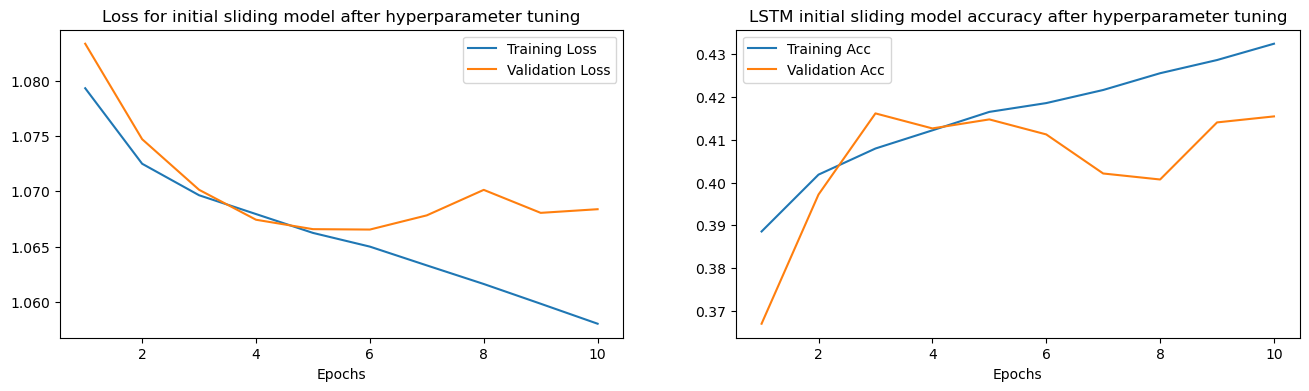

In [589]:
# Plotting the loss on the first subplot
hist_sl_init = model_LSTM_slide_initial_fit.history
fig = plt.figure(figsize = (16, 4))
ax = fig.add_subplot(1, 2, 1)
plt.plot(range(1, num_epochs+1), hist_sl_init['loss'], label='Training Loss')
plt.plot(range(1, num_epochs+1), hist_sl_init['val_loss'], label='Validation Loss')
plt.legend()
ax.set_xlabel('Epochs')
ax.set_title('Loss for initial sliding model after hyperparameter tuning');

# Plotting the accuracy on the second subplot
ax = fig.add_subplot(1, 2, 2)
plt.plot(range(1, num_epochs+1), hist_sl_init['accuracy'], label='Training Acc')
plt.plot(range(1, num_epochs+1), hist_sl_init['val_accuracy'], label='Validation Acc')
plt.legend()
ax.set_xlabel('Epochs')
ax.set_title('LSTM initial sliding model accuracy after hyperparameter tuning')
plt.show()

In [590]:
print("Final training accuracy:", hist_sl_init['accuracy'][-1])
print("Final validation accuracy:", hist_sl_init['val_accuracy'][-1])

Final training accuracy: 0.4324120581150055
Final validation accuracy: 0.41543859243392944


Because we have less train data to work with for this initial window, it would make sense that the accuracies would be a bit lower compared to before. However, they're still comparable, and they will hopefully improve as we get more data in.

In [592]:
# Evaluating the model against X_test and Y_test
model_LSTM_slide_initial.evaluate(X_test_init, Y_test_init)

15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.3813 - loss: 1.1384


[1.1180955171585083, 0.3936842083930969]

As expected, our test accuracy took a hit, again for the reason above. We can confirm our observations with a confusion matrix, but we'll save this model first so we don't lose it.

In [614]:
# Saving this model as the initial basis for learning
model_LSTM_slide_initial.save('model_LSTM_slide_initial_2025_03_25.keras')  # .keras format (preferred as of TF 2.11+)

#### Plotting a confusion matrix for the test predictions

In [593]:
# Getting Y_test_pred for the model
Y_test_pred = model_LSTM_slide_initial.predict(X_test_init)
Y_test_pred_perc = Y_test_pred.copy()
Y_test_pred = np.argmax(Y_test_pred, axis = 1)

# Getting the confusion matrix using Y_test and Y_test_pred
cf = confusion_matrix(
    Y_test_init,
    Y_test_pred
)

print('Generating the confusion matrix using confusion_matrix from '
  'sklearn.metrics:')
cf

15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
Generating the confusion matrix using confusion_matrix from sklearn.metrics:


array([[ 59,  29,  87],
       [ 46,  45, 105],
       [ 16,   5,  83]])

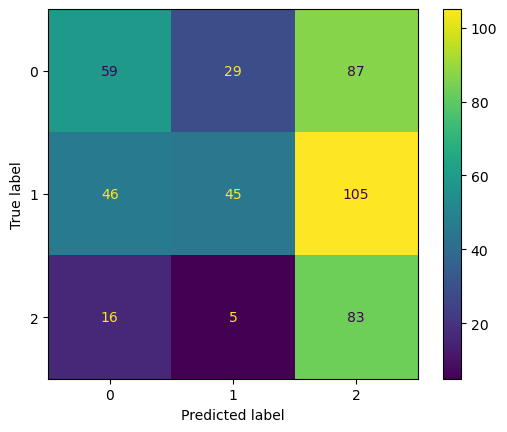

In [595]:
# Plotting the confusion matrix for the model
disp = ConfusionMatrixDisplay.from_predictions(
    y_true=Y_test_init,
    y_pred=Y_test_pred,
    labels=None
)

And we do indeed confirm our results, with this initial model not performing great. However, let's see what happens when we implement our prediction threshold.

#### Further analyses with prediction threshold

In [613]:
# Setting a prediction threshold of 0.5
pred_threshold = 0.5

# Getting the Y_test_pred_thresh
Y_test_pred_thresh = model_LSTM_slide_initial.predict(X_test_init)
Y_test_pred_thresh = np.where(Y_test_pred_thresh[:, 0] > pred_threshold, 0,
                                  np.where(Y_test_pred_thresh[:, 2] > pred_threshold, 2, 1))

# Getting the confusion matrix with the threshold
cf_thresh = confusion_matrix(
    Y_test_init,
    Y_test_pred_thresh
)

cf_thresh

15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step


array([[  9, 148,  18],
       [  3, 182,  11],
       [  1,  75,  28]])

While the results aren't perfect, we do see that we actually predict classes 0 and 2 with relatively good precision. In both cases, the true class (Class 0 or Class 2) has more predictions than its opposite class, and our model is at least somewhat confident in its results. Now, let's continue running the model to see what we get.

### Incremental fine-tuning as we slide the window to incorporate new days of data
This is where we implement the process of incrementally adding a set number of days each time a new day of training data appears. In this case, we opted to train the model on the most recent **100** days with respect to each new day (which will ultimately be the new test day for all 475 tickers).

In [692]:
# Loading the model (if we want to use it)
model_LSTM_slide_initial_2025_03_25 = load_model('model_LSTM_slide_initial_2025_03_25.keras')

**Note:** We're only running **2** days of incremental fine tuning just to see how well this will perform before we run more tests. Because the next test day is the 801st day in our dataset, we'll start on day 701 for our incremental fine-tuning.

In [683]:
# Setting seed for consistent re-runs
tf.random.set_seed(1234)
np.random.seed(1234)

# Setting the window size to slide over and other initial parameters
first_slide_day = 701
slide_amount = 1  # Amount to slide each window
window_size_slide = 100
train_window_slide = 96
val_window_slide = 3
test_window_slide = 1
num_epochs_slide = 1

# Getting a dictionary of different metrics
metrics_dict = {}

# Recompiling the model to use SGD with a lower learning rate (keeps weights, but does reset the optimizer state)
optimizer_slide = SGD(learning_rate=0.0001, momentum=0.1)
model_LSTM_slide_initial_2025_03_25.compile(
    optimizer = optimizer_slide,
    loss = tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics = [metric])

# If we want to keep the Adam optimizer instead:
# Lowering the learning rate so we still train but hopefully not overfit 
# model_LSTM_slide_initial_2025_03_25.optimizer.learning_rate.assign(1e-5)
# model_LSTM_slide_initial.optimizer.learning_rate.assign(1e-5)  # If we want to continue from the notebook

# Looping over the window range as we slide the window
# for start_day_num in range(first_slide_day, num_sequences_per_ticker - window_size_slide + 1, slide_amount):
for start_day_num in range(first_slide_day, 703, slide_amount):

    # Getting the windows for X and Y
    X_window = X_data_smaller[(unique_tickers * start_day_num):(unique_tickers * (start_day_num + window_size_slide))]
    Y_window = Y_data_smaller[(unique_tickers * start_day_num):(unique_tickers * (start_day_num + window_size_slide))]

    # Splitting data into train, val, and test sets
    X_train_sl, Y_train_sl, X_val_sl, Y_val_sl, X_test_sl, Y_test_sl = train_val_test_seq_split(
        X_window, Y_window, unique_tickers, train_window_slide, val_window_slide, test_window_slide)
    
    # Fitting the model again for each slide
    model_LSTM_slide_fit = model_LSTM_slide_initial_2025_03_25.fit(
        x = X_train_sl,
        y = Y_train_sl,
        validation_data = [X_val_sl, Y_val_sl],
        epochs = num_epochs_slide,
        batch_size = batch_size,
        verbose = 1)

    # Getting the final training and validation accuracies
    hist_sl = model_LSTM_slide_fit.history
    train_accuracy_sl = hist_sl['accuracy'][-1]
    val_accuracy_sl = hist_sl['val_accuracy'][-1]

    # Getting the test accuracy
    Y_test_sl_pred = model_LSTM_slide_initial_2025_03_25.predict(X_test_sl)  # Softmax predictions
    Y_test_sl_pred_no_thresh = np.argmax(Y_test_sl_pred, axis = 1)  # Argmax of predictions
    test_accuracy_sl = (Y_test_sl_pred_no_thresh == Y_test_sl).sum() / len(Y_test_sl)

    # Getting the no threshold confusion matrix using Y_test_sl and Y_test_sl_pred
    cf_no_thresh = confusion_matrix(
        Y_test_sl,
        Y_test_sl_pred_no_thresh)

    # Creating and appending metrics list to metrics_dict
    metrics_dict[start_day_num] = [train_accuracy_sl, val_accuracy_sl, test_accuracy_sl, cf_no_thresh]

    # Setting different prediction thresholds and getting the Y_test_sl_pred_thresh confusion matrix for each
    thresholds_list = [0.4, 0.45, 0.5, 0.55, 0.6, 0.65, 0.7, 0.75, 0.8]
    for threshold in thresholds_list:
        Y_test_sl_pred_thresh = np.where(Y_test_sl_pred[:, 0] > threshold, 0,
                                     np.where(Y_test_sl_pred[:, 2] > threshold, 2, 1))
        
        # Getting the confusion matrix for this threshold and appending it to the list in the dictionary
        cf_thresh = confusion_matrix(
            Y_test_sl,
            Y_test_sl_pred_thresh)
        metrics_dict[start_day_num].append(cf_thresh)
    

179/179 ━━━━━━━━━━━━━━━━━━━━ 24s 132ms/step - accuracy: 0.4203 - loss: 1.0694 - val_accuracy: 0.4133 - val_loss: 1.0863
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
179/179 ━━━━━━━━━━━━━━━━━━━━ 24s 134ms/step - accuracy: 0.4185 - loss: 1.0697 - val_accuracy: 0.3768 - val_loss: 1.0842
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step


Here is what our metrics_dict composes of: it's a dictionary with the key as the starting date and its values as a list containing the following metrics:
1. Training accuracy
2. Validation accuracy
3. Test accuracy
4. Full confusion matrix for the predictions
5. Confusion matrix with a prediction threshold of 0.40 for Class 0 and Class 2 (with a default of Class 1)
6. Confusion matrix with a prediction threshold of 0.45...
7. Confusion matrix with a prediction threshold of 0.50...
8. Confusion matrix with a prediction threshold of 0.55...
9. Confusion matrix with a prediction threshold of 0.60...
10. Confusion matrix with a prediction threshold of 0.65...
11. Confusion matrix with a prediction threshold of 0.70...
12. Confusion matrix with a prediction threshold of 0.75...
13. Confusion matrix with a prediction threshold of 0.80...

In [684]:
metrics_dict

{701: [0.4183114171028137,
  0.41333332657814026,
  0.3136842105263158,
  array([[ 73,  50, 174],
         [ 13,  25,  23],
         [ 35,  31,  51]]),
  array([[ 46, 139, 112],
         [  3,  49,   9],
         [ 15,  74,  28]]),
  array([[ 20, 223,  54],
         [  1,  54,   6],
         [  3, 101,  13]]),
  array([[ 13, 253,  31],
         [  1,  58,   2],
         [  2, 106,   9]]),
  array([[  8, 273,  16],
         [  0,  59,   2],
         [  1, 111,   5]]),
  array([[  5, 286,   6],
         [  0,  59,   2],
         [  1, 112,   4]]),
  array([[  3, 291,   3],
         [  0,  61,   0],
         [  1, 113,   3]]),
  array([[  2, 293,   2],
         [  0,  61,   0],
         [  1, 113,   3]]),
  array([[  2, 294,   1],
         [  0,  61,   0],
         [  0, 116,   1]]),
  array([[  2, 295,   0],
         [  0,  61,   0],
         [  0, 116,   1]])],
 702: [0.4187280833721161,
  0.37684211134910583,
  0.3157894736842105,
  array([[ 80,  25, 170],
         [ 31,  25,  56],
   

Overall, our results are quite disappointing, with the model failing to accurately predict the two new days for pretty much all of the thresholds. To be thorough, we did also try numerous different learning rates and even different optimizers, but none of them performed as well as what's shown above. We may need to try a different strategy for continuous training, but for now, it appears that incremental fine-tuning with new, daily pieces of time-series data is not ideal. It almost seems like the training dataset **needs** all the data up till the day of the test set, and this is somewhat worrying for performance. Therefore, we will try once more with our model, but rebuilding it every time and re-running with new data.

### Re-training the model as we slide the window for new data dates
What we're doing here is instead of continuing to train on the 100 most recent days of data for each new day, we're expanding to the entire 800 days.

In [699]:
# Setting seed for consistent re-runs
tf.random.set_seed(1234)
np.random.seed(1234)

# Setting hyperparameters
seq_length = X_data_smaller.shape[1]
num_features = X_data_smaller.shape[2]
n_classes = 3
LSTM_units = 256
learning_rate = 0.0001
optimizer = 'Adam'
metric = 'accuracy'
num_epochs = 10
batch_size = 256

In [696]:
# Setting seed for consistent re-runs
tf.random.set_seed(1234)
np.random.seed(1234)

# Setting the window size to slide over and other initial parameters
first_slide_day = 1
slide_amount = 1  # Amount to slide each window
window_size_slide = 800
train_window_slide = 796
val_window_slide = 3
test_window_slide = 1
num_epochs_slide = 1

# Getting a dictionary of different metrics
metrics_dict = {}

# Looping over the window range as we slide the window
# for start_day_num in range(first_slide_day, num_sequences_per_ticker - window_size_slide + 1, slide_amount):
for start_day_num in range(first_slide_day, 3, slide_amount):

    # Getting the windows for X and Y
    X_window = X_data_smaller[(unique_tickers * start_day_num):(unique_tickers * (start_day_num + window_size_slide))]
    Y_window = Y_data_smaller[(unique_tickers * start_day_num):(unique_tickers * (start_day_num + window_size_slide))]

    # Splitting data into train, val, and test sets
    X_train_sl, Y_train_sl, X_val_sl, Y_val_sl, X_test_sl, Y_test_sl = train_val_test_seq_split(
        X_window, Y_window, unique_tickers, train_window_slide, val_window_slide, test_window_slide)

    # Building the model from scratch
    model_LSTM_slide = build_LSTM_model_slide(seq_length=seq_length,
                                                  num_features=num_features,
                                                  n_classes=n_classes,
                                                  LSTM_units=LSTM_units,
                                                  learning_rate=learning_rate,
                                                  optimizer=optimizer,
                                                  metric=metric)
    
    # Fitting the model again for each slide
    model_LSTM_slide_fit = model_LSTM_slide.fit(
        x = X_train_sl,
        y = Y_train_sl,
        validation_data = [X_val_sl, Y_val_sl],
        epochs = num_epochs,
        batch_size = batch_size,
        verbose = 1)
    
    # Getting the final training and validation accuracies
    hist_sl = model_LSTM_slide_fit.history
    train_accuracy_sl = hist_sl['accuracy'][-1]
    val_accuracy_sl = hist_sl['val_accuracy'][-1]

    # Getting the test accuracy
    Y_test_sl_pred = model_LSTM_slide.predict(X_test_sl)  # Softmax predictions
    Y_test_sl_pred_no_thresh = np.argmax(Y_test_sl_pred, axis = 1)  # Argmax of predictions
    test_accuracy_sl = (Y_test_sl_pred_no_thresh == Y_test_sl).sum() / len(Y_test_sl)

    # Getting the no threshold confusion matrix using Y_test_sl and Y_test_sl_pred
    cf_no_thresh = confusion_matrix(
        Y_test_sl,
        Y_test_sl_pred_no_thresh)

    # Creating and appending metrics list to metrics_dict
    metrics_dict[start_day_num] = [train_accuracy_sl, val_accuracy_sl, test_accuracy_sl, cf_no_thresh]

    # Setting different prediction thresholds and getting the Y_test_sl_pred_thresh confusion matrix for each
    thresholds_list = [0.4, 0.45, 0.5, 0.55, 0.6, 0.65, 0.7, 0.75, 0.8]
    for threshold in thresholds_list:
        Y_test_sl_pred_thresh = np.where(Y_test_sl_pred[:, 0] > threshold, 0,
                                     np.where(Y_test_sl_pred[:, 2] > threshold, 2, 1))
        
        # Getting the confusion matrix for this threshold and appending it to the list in the dictionary
        cf_thresh = confusion_matrix(
            Y_test_sl,
            Y_test_sl_pred_thresh)
        metrics_dict[start_day_num].append(cf_thresh)
    

Epoch 1/10
1477/1477 ━━━━━━━━━━━━━━━━━━━━ 193s 130ms/step - accuracy: 0.3796 - loss: 1.0855 - val_accuracy: 0.3846 - val_loss: 1.0808
Epoch 2/10
1477/1477 ━━━━━━━━━━━━━━━━━━━━ 195s 132ms/step - accuracy: 0.3976 - loss: 1.0734 - val_accuracy: 0.3832 - val_loss: 1.0802
Epoch 3/10
1477/1477 ━━━━━━━━━━━━━━━━━━━━ 203s 138ms/step - accuracy: 0.4041 - loss: 1.0705 - val_accuracy: 0.3916 - val_loss: 1.0811
Epoch 4/10
1477/1477 ━━━━━━━━━━━━━━━━━━━━ 202s 137ms/step - accuracy: 0.4095 - loss: 1.0685 - val_accuracy: 0.3888 - val_loss: 1.0822
Epoch 5/10
1477/1477 ━━━━━━━━━━━━━━━━━━━━ 203s 138ms/step - accuracy: 0.4116 - loss: 1.0672 - val_accuracy: 0.3888 - val_loss: 1.0821
Epoch 6/10
1477/1477 ━━━━━━━━━━━━━━━━━━━━ 204s 138ms/step - accuracy: 0.4153 - loss: 1.0659 - val_accuracy: 0.3916 - val_loss: 1.0826
Epoch 7/10
1477/1477 ━━━━━━━━━━━━━━━━━━━━ 203s 138ms/step - accuracy: 0.4192 - loss: 1.0642 - val_accuracy: 0.3867 - val_loss: 1.0826
Epoch 8/10
1477/1477 ━━━━━━━━━━━━━━━━━━━━ 203s 137ms/step - ac

The metrics_dict is the same as above, but our train/val/test window increased from the last 100 to the last 800 days, and we've re-trained the model at every step.

In [697]:
metrics_dict

{1: [0.4295477271080017,
  0.3936842083930969,
  0.26526315789473687,
  array([[ 37,  65, 195],
         [  6,  33,  22],
         [ 21,  40,  56]]),
  array([[ 27, 134, 136],
         [  3,  46,  12],
         [ 10,  79,  28]]),
  array([[ 16, 212,  69],
         [  1,  53,   7],
         [  2, 102,  13]]),
  array([[  9, 251,  37],
         [  1,  58,   2],
         [  1, 106,  10]]),
  array([[  6, 270,  21],
         [  0,  59,   2],
         [  1, 109,   7]]),
  array([[  3, 286,   8],
         [  0,  59,   2],
         [  1, 111,   5]]),
  array([[  3, 290,   4],
         [  0,  60,   1],
         [  1, 113,   3]]),
  array([[  2, 294,   1],
         [  0,  61,   0],
         [  1, 114,   2]]),
  array([[  2, 295,   0],
         [  0,  61,   0],
         [  0, 116,   1]]),
  array([[  1, 296,   0],
         [  0,  61,   0],
         [  0, 116,   1]])],
 2: [0.4296746850013733,
  0.36210525035858154,
  0.30105263157894735,
  array([[ 64,  23, 188],
         [ 22,  28,  62],
      

From the confusion matrices above, it's clear to us that this model does not perform well at all. Even for higher thresholds, our precision for classes 0 and 2 are quite poor, and it doesn't seem like our model is really recognizing anything. Furthemore, even though this model is the same as before with the same amount of data (but just shifted over by one day), it appears our previous success was simply variance and not actual model performance. This is obviously quite discouraging, but it shouldn't be too surprising based on what we've seen over these past few models.

Nevertheless, we will try one last model, this time simplifying the LSTM units to 128 (for speed and generalization) and increasing our train/val/test window size even more.

## LSTM Classification (even longer series, 896/3/1 window, sliding simpler model, 128 LSTM units)
We will keep a sequence length of 50, increase our sliding window to 896/3/1, and lower our LSTM units back down to 128.

### Generating X continuous series sequences and Y continuous labels

In [718]:
# Creating sequences for LSTM model
seq_length = 50
group_col = 'Ticker'
target_col = 'Close_Open_Diff_Ternary'
drop_cols = ['Date_col', 'Close_Open_Diff_Perc']

X_data_smaller, Y_data_smaller = create_sequences_grouped(data_smaller, seq_length, group_col, target_col, drop_cols)

In [721]:
# Confirming shapes
print('Shape of X_data_smaller:', X_data_smaller.shape)
print('Shape of Y_data_smaller:', Y_data_smaller.shape, '\n')

# Confirming that we should have the correct number of sequences in X_data_smaller
unique_tickers = data_smaller['Ticker'].nunique()
unique_dates = data_smaller['Date_col'].nunique()
expected_num_sequences = unique_tickers * (unique_dates - seq_length + 1)

print('Number of unique tickers in data_smaller:', unique_tickers)
print('Number of unique dates in data_smaller:', unique_dates)
print('Chosen sequence length:', seq_length)
print('Number of sequences assuming the above seq_length:', unique_dates - seq_length + 1)
print('(We need to add 1 to the end to account for either the beginning or the end. For example, if we had 12 observations with a window')
print('of 5, we would need 12 - 5 + 1 = 8 sequences, the first one being having indices from [0:5], and the last from [7:12].)\n')
print('Total number of data sequences expected:', expected_num_sequences)
print('Total number of data sequences achieved:', X_data_smaller.shape[0])

Shape of X_data_smaller: (430350, 50, 32)
Shape of Y_data_smaller: (430350,) 

Number of unique tickers in data_smaller: 475
Number of unique dates in data_smaller: 955
Chosen sequence length: 50
Number of sequences assuming the above seq_length: 906
(We need to add 1 to the end to account for either the beginning or the end. For example, if we had 12 observations with a window
of 5, we would need 12 - 5 + 1 = 8 sequences, the first one being having indices from [0:5], and the last from [7:12].)

Total number of data sequences expected: 430350
Total number of data sequences achieved: 430350


### Defining function for splitting sequence data into train, val, and test splits

In [722]:
# Defining function to split sequence data into train, val, test splits with split size (in terms of # of days)
def train_val_test_seq_split(X_window, Y_window, num_tickers, train_size, val_size, test_size):
    X_data = X_window.copy()
    Y_data = Y_window.copy()

    if (X_data.shape[0]/num_tickers) != (train_size + val_size + test_size):
        print("Train + val + test sizes do not much number of dates")
        return None

    X_train = X_data[:(num_tickers * train_size)]
    Y_train = Y_data[:(num_tickers * train_size)]
    X_val = X_data[(num_tickers * train_size):(num_tickers * (train_size + val_size))]
    Y_val = Y_data[(num_tickers * train_size):(num_tickers * (train_size + val_size))]
    X_test = X_data[(num_tickers * (train_size + val_size)):]
    Y_test = Y_data[(num_tickers * (train_size + val_size)):]

    return X_train, Y_train, X_val, Y_val, X_test, Y_test

### Defining function for building and compiling LSTM model for sliding train/val/test windows
This is the exact same function as before, but we're placing it here again for consistency purposes.

In [723]:
# Defining a function to create the LSTM model for sliding train, val, and test windows
def build_LSTM_model_slide(seq_length,
                     num_features,
                     n_classes,
                     LSTM_units=256,
                     learning_rate=0.01,
                     optimizer='SGD',
                     metric='accuracy'):

    # Resetting tf for consistent results
    tf.keras.backend.clear_session()
    np.random.seed(0)
    tf.random.set_seed(0)
    
    # Building a model using tf Sequential
    model = tf.keras.Sequential()

    # Input layer
    model.add(tf.keras.Input(shape=(seq_length, num_features), name='Input'))
    
    # LSTM layer
    model.add(LSTM(units=LSTM_units, return_sequences=False, name='LSTM'))

    # Dropout layer
    model.add(Dropout(0.3, name='Dropout'))

    # Output layer
    model.add(tf.keras.layers.Dense(
      units = n_classes,
      activation = 'softmax',
      name = 'Output'
    ))
    
    # Setting optimizer and specific learning rate
    optimizer_class = getattr(tf.keras.optimizers, optimizer)
    optimizer_true = optimizer_class(learning_rate=learning_rate)
    
    # Compiling the model
    model.compile(
      optimizer = optimizer_true,
      loss = tf.keras.losses.SparseCategoricalCrossentropy(),
      metrics = [metric]
    )
    
    return model

### Running the LSTM model with the sliding train/val/test window
This time, we'll be running the model with 128 LSTM units rather than 256 LSTM units.

In [724]:
# Setting seed for consistent re-runs
tf.random.set_seed(1234)
np.random.seed(1234)

# Setting hyperparameters
seq_length = X_data_smaller.shape[1]
num_features = X_data_smaller.shape[2]
n_classes = 3
LSTM_units = 128
learning_rate = 0.0001
optimizer = 'Adam'
metric = 'accuracy'
num_epochs = 10
batch_size = 256

In [725]:
# Defining initial variables for the first window
num_sequences_per_ticker = unique_dates - seq_length + 1  # unique_dates is from above
window_size_initial = 900  # 896 + 3 + 1
train_window = 896
val_window = 3
test_window = 1

# Getting the initial windows for X and Y
X_window_initial = X_data_smaller[:(unique_tickers * window_size_initial)]
Y_window_initial = Y_data_smaller[:(unique_tickers * window_size_initial)]

# Splitting the data into train, val, and test sets
X_train_init, Y_train_init, X_val_init, Y_val_init, X_test_init, Y_test_init = train_val_test_seq_split(
    X_window_initial, Y_window_initial, unique_tickers, train_window, val_window, test_window)

print("X_train_init shape:", X_train_init.shape)
print("Y_train_init shape:", Y_train_init.shape)
print("X_val_init shape:", X_val_init.shape)
print("Y_val_init shape:", Y_val_init.shape)
print("X_test_init shape:", X_test_init.shape)
print("Y_test_init shape:", Y_test_init.shape)

X_train_init shape: (425600, 50, 32)
Y_train_init shape: (425600,)
X_val_init shape: (1425, 50, 32)
Y_val_init shape: (1425,)
X_test_init shape: (475, 50, 32)
Y_test_init shape: (475,)


In [726]:
# Building the initial model
model_LSTM_slide_initial = build_LSTM_model_slide(seq_length=seq_length,
                                                  num_features=num_features,
                                                  n_classes=n_classes,
                                                  LSTM_units=LSTM_units,
                                                  learning_rate=learning_rate,
                                                  optimizer=optimizer,
                                                  metric=metric)
model_LSTM_slide_initial.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ LSTM (LSTM)                     │ (None, 128)            │        82,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output (Dense)                  │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 82,819 (323.51 KB)

 Trainable params: 82,819 (323.51 KB)

 Non-trainable params: 0 (0.00 B)

In [727]:
# Fitting the model
model_LSTM_slide_initial_fit = model_LSTM_slide_initial.fit(
    x = X_train_init,
    y = Y_train_init,
    validation_data = [X_val_init, Y_val_init],
    epochs = num_epochs,
    batch_size = batch_size,
    verbose = 1)

Epoch 1/10
1663/1663 ━━━━━━━━━━━━━━━━━━━━ 154s 92ms/step - accuracy: 0.3719 - loss: 1.0910 - val_accuracy: 0.3726 - val_loss: 1.0718
Epoch 2/10
1663/1663 ━━━━━━━━━━━━━━━━━━━━ 160s 96ms/step - accuracy: 0.3964 - loss: 1.0752 - val_accuracy: 0.4470 - val_loss: 1.0552
Epoch 3/10
1663/1663 ━━━━━━━━━━━━━━━━━━━━ 157s 94ms/step - accuracy: 0.4027 - loss: 1.0720 - val_accuracy: 0.4828 - val_loss: 1.0496
Epoch 4/10
1663/1663 ━━━━━━━━━━━━━━━━━━━━ 150s 90ms/step - accuracy: 0.4091 - loss: 1.0697 - val_accuracy: 0.4905 - val_loss: 1.0429
Epoch 5/10
1663/1663 ━━━━━━━━━━━━━━━━━━━━ 146s 88ms/step - accuracy: 0.4124 - loss: 1.0680 - val_accuracy: 0.5088 - val_loss: 1.0400
Epoch 6/10
1663/1663 ━━━━━━━━━━━━━━━━━━━━ 148s 89ms/step - accuracy: 0.4155 - loss: 1.0669 - val_accuracy: 0.5144 - val_loss: 1.0370
Epoch 7/10
1663/1663 ━━━━━━━━━━━━━━━━━━━━ 144s 87ms/step - accuracy: 0.4172 - loss: 1.0658 - val_accuracy: 0.5179 - val_loss: 1.0319
Epoch 8/10
1663/1663 ━━━━━━━━━━━━━━━━━━━━ 146s 88ms/step - accuracy: 

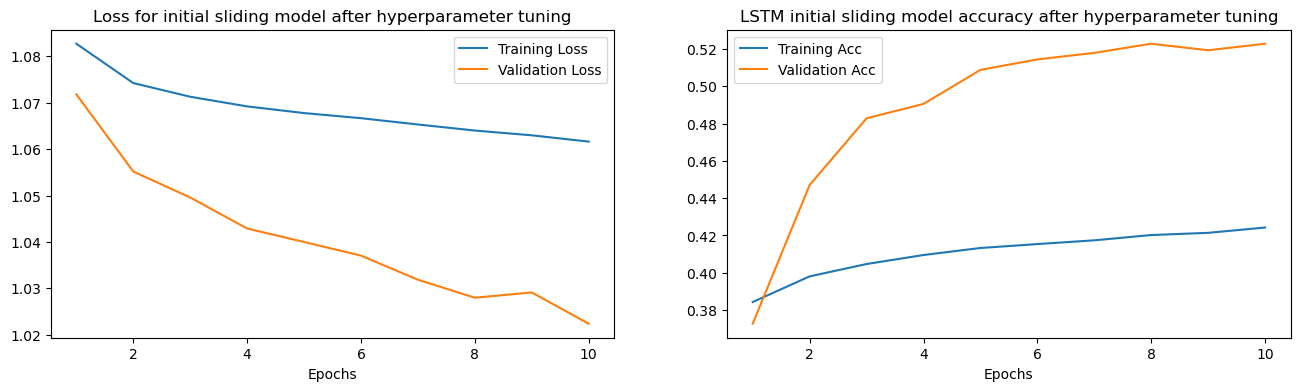

In [728]:
# Plotting the loss on the first subplot
hist_sl_init = model_LSTM_slide_initial_fit.history
fig = plt.figure(figsize = (16, 4))
ax = fig.add_subplot(1, 2, 1)
plt.plot(range(1, num_epochs+1), hist_sl_init['loss'], label='Training Loss')
plt.plot(range(1, num_epochs+1), hist_sl_init['val_loss'], label='Validation Loss')
plt.legend()
ax.set_xlabel('Epochs')
ax.set_title('Loss for initial sliding model after hyperparameter tuning');

# Plotting the accuracy on the second subplot
ax = fig.add_subplot(1, 2, 2)
plt.plot(range(1, num_epochs+1), hist_sl_init['accuracy'], label='Training Acc')
plt.plot(range(1, num_epochs+1), hist_sl_init['val_accuracy'], label='Validation Acc')
plt.legend()
ax.set_xlabel('Epochs')
ax.set_title('LSTM initial sliding model accuracy after hyperparameter tuning')
plt.show()

In [729]:
print("Final training accuracy:", hist_sl_init['accuracy'][-1])
print("Final validation accuracy:", hist_sl_init['val_accuracy'][-1])

Final training accuracy: 0.4242246150970459
Final validation accuracy: 0.5228070020675659


The training and validation accuracies are comparable to before, which gives us at least some confidence that this model works reasonably well.

In [730]:
# Evaluating the model against X_test and Y_test
model_LSTM_slide_initial.evaluate(X_test_init, Y_test_init)

15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.1472 - loss: 1.1384


[1.1323004961013794, 0.1621052622795105]

The test accuracy here looks absolutely atrocious. However, analyzing the stock market on this date reveals that this particular day (12/20/24) was incredibly bullish, so our model may not have been able to capture that trend. Let's analyze our confusion matrix to see if we can confirm this observation.

#### Plotting a confusion matrix for the test predictions

In [732]:
# Getting Y_test_pred for the model
Y_test_pred = model_LSTM_slide_initial.predict(X_test_init)
Y_test_pred_perc = Y_test_pred.copy()
Y_test_pred = np.argmax(Y_test_pred, axis = 1)

# Getting the confusion matrix using Y_test and Y_test_pred
cf = confusion_matrix(
    Y_test_init,
    Y_test_pred
)

print('Generating the confusion matrix using confusion_matrix from '
  'sklearn.metrics:')
cf

15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
Generating the confusion matrix using confusion_matrix from sklearn.metrics:


array([[ 14,   0,   9],
       [ 45,   0,  13],
       [329,   2,  63]])

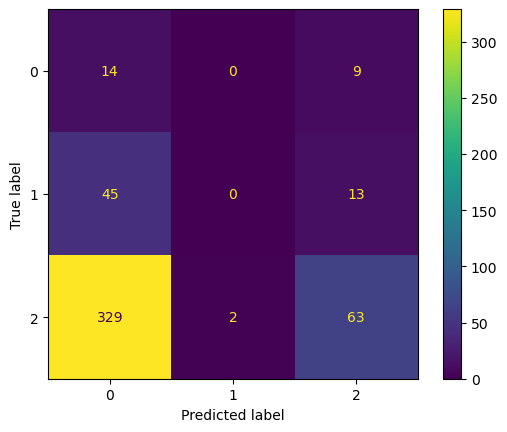

In [733]:
# Plotting the confusion matrix for the model
disp = ConfusionMatrixDisplay.from_predictions(
    y_true=Y_test_init,
    y_pred=Y_test_pred,
    labels=None
)

As expected, because of how bullish this day was, most of the stocks were positive, and our model was unable to determine that. Even with a prediction threshold, it's unlikely that our model will be able to tell the difference.

#### Further analyses with prediction threshold
We changed the prediction threshold from 0.4 to 0.9, but found that a threshold of 0.5 worked the best.

In [734]:
# Setting a prediction threshold of 0.5
pred_threshold = 0.5

# Getting the Y_test_pred_thresh
Y_test_pred_thresh = model_LSTM_slide_initial.predict(X_test_init)
Y_test_pred_thresh = np.where(Y_test_pred_thresh[:, 0] > pred_threshold, 0,
                                  np.where(Y_test_pred_thresh[:, 2] > pred_threshold, 2, 1))

# Getting the confusion matrix with the threshold
cf_thresh = confusion_matrix(
    Y_test_init,
    Y_test_pred_thresh
)

cf_thresh

15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step


array([[  6,  12,   5],
       [ 18,  36,   4],
       [142, 239,  13]])

Once again, we see see that a prediction threshold doesn't matter much, as the market so heavily bullish on this day. Nevertheless, let's continue our sliding window (for the remaining 6 days in our dataset) and see what results we get.

### Re-training the model as we slide the window for new data dates

In [735]:
# Setting seed for consistent re-runs
tf.random.set_seed(1234)
np.random.seed(1234)

# Setting hyperparameters
seq_length = X_data_smaller.shape[1]
num_features = X_data_smaller.shape[2]
n_classes = 3
LSTM_units = 128
learning_rate = 0.0001
optimizer = 'Adam'
metric = 'accuracy'
num_epochs = 10
batch_size = 256

In [755]:
# Setting seed for consistent re-runs
tf.random.set_seed(1234)
np.random.seed(1234)

# Setting the window size to slide over and other initial parameters
first_slide_day = 1
slide_amount = 1  # Amount to slide each window
window_size_slide = 900
train_window_slide = 896
val_window_slide = 3
test_window_slide = 1

# Getting a dictionary of different metrics
metrics_dict = {}

# Looping over the window range as we slide the window
# for start_day_num in range(first_slide_day, 3, slide_amount):
for start_day_num in range(first_slide_day, num_sequences_per_ticker - window_size_slide + 1, slide_amount):

    # Getting the windows for X and Y
    X_window = X_data_smaller[(unique_tickers * start_day_num):(unique_tickers * (start_day_num + window_size_slide))]
    Y_window = Y_data_smaller[(unique_tickers * start_day_num):(unique_tickers * (start_day_num + window_size_slide))]

    # Splitting data into train, val, and test sets
    X_train_sl, Y_train_sl, X_val_sl, Y_val_sl, X_test_sl, Y_test_sl = train_val_test_seq_split(
        X_window, Y_window, unique_tickers, train_window_slide, val_window_slide, test_window_slide)

    # Building the model from scratch
    model_LSTM_slide = build_LSTM_model_slide(seq_length=seq_length,
                                                  num_features=num_features,
                                                  n_classes=n_classes,
                                                  LSTM_units=LSTM_units,
                                                  learning_rate=learning_rate,
                                                  optimizer=optimizer,
                                                  metric=metric)
    
    # Fitting the model again for each slide
    model_LSTM_slide_fit = model_LSTM_slide.fit(
        x = X_train_sl,
        y = Y_train_sl,
        validation_data = [X_val_sl, Y_val_sl],
        epochs = num_epochs,
        batch_size = batch_size,
        verbose = 1)
    
    # Getting the final training and validation accuracies
    hist_sl = model_LSTM_slide_fit.history
    train_accuracy_sl = hist_sl['accuracy'][-1]
    val_accuracy_sl = hist_sl['val_accuracy'][-1]

    # Getting the test accuracy
    Y_test_sl_pred = model_LSTM_slide.predict(X_test_sl)  # Softmax predictions
    Y_test_sl_pred_no_thresh = np.argmax(Y_test_sl_pred, axis = 1)  # Argmax of predictions
    test_accuracy_sl = (Y_test_sl_pred_no_thresh == Y_test_sl).sum() / len(Y_test_sl)

    # Getting the no threshold confusion matrix using Y_test_sl and Y_test_sl_pred
    cf_no_thresh = confusion_matrix(
        Y_test_sl,
        Y_test_sl_pred_no_thresh)

    # Creating and appending metrics list to metrics_dict
    metrics_dict[start_day_num] = [train_accuracy_sl, val_accuracy_sl, test_accuracy_sl, cf_no_thresh]

    # Setting different prediction thresholds and getting the Y_test_sl_pred_thresh confusion matrix for each
    thresholds_list = [0.4, 0.45, 0.5, 0.55, 0.6, 0.65, 0.7, 0.75, 0.8]
    for threshold in thresholds_list:
        Y_test_sl_pred_thresh = np.where(Y_test_sl_pred[:, 0] > threshold, 0,
                                     np.where(Y_test_sl_pred[:, 2] > threshold, 2, 1))
        
        # Getting the confusion matrix for this threshold and appending it to the list in the dictionary
        cf_thresh = confusion_matrix(
            Y_test_sl,
            Y_test_sl_pred_thresh)
        metrics_dict[start_day_num].append(cf_thresh)
    

Epoch 1/10
1663/1663 ━━━━━━━━━━━━━━━━━━━━ 162s 97ms/step - accuracy: 0.3766 - loss: 1.0894 - val_accuracy: 0.3340 - val_loss: 1.0577
Epoch 2/10
1663/1663 ━━━━━━━━━━━━━━━━━━━━ 163s 98ms/step - accuracy: 0.3980 - loss: 1.0750 - val_accuracy: 0.3768 - val_loss: 1.0509
Epoch 3/10
1663/1663 ━━━━━━━━━━━━━━━━━━━━ 164s 98ms/step - accuracy: 0.4049 - loss: 1.0713 - val_accuracy: 0.4119 - val_loss: 1.0435
Epoch 4/10
1663/1663 ━━━━━━━━━━━━━━━━━━━━ 153s 92ms/step - accuracy: 0.4092 - loss: 1.0693 - val_accuracy: 0.4189 - val_loss: 1.0422
Epoch 5/10
1663/1663 ━━━━━━━━━━━━━━━━━━━━ 154s 93ms/step - accuracy: 0.4123 - loss: 1.0678 - val_accuracy: 0.4316 - val_loss: 1.0398
Epoch 6/10
1663/1663 ━━━━━━━━━━━━━━━━━━━━ 162s 97ms/step - accuracy: 0.4149 - loss: 1.0665 - val_accuracy: 0.4295 - val_loss: 1.0389
Epoch 7/10
1663/1663 ━━━━━━━━━━━━━━━━━━━━ 159s 96ms/step - accuracy: 0.4168 - loss: 1.0655 - val_accuracy: 0.4309 - val_loss: 1.0383
Epoch 8/10
1663/1663 ━━━━━━━━━━━━━━━━━━━━ 159s 96ms/step - accuracy: 

In [782]:
# Printing the full metrics_dict just to see it:
metrics_dict

{1: [0.42536184191703796,
  0.4343859553337097,
  0.5557894736842105,
  array([[  6,   8,  27],
         [  5, 116,  94],
         [  7,  70, 142]]),
  array([[  7,  19,  15],
         [  3, 153,  59],
         [ 10, 118,  91]]),
  array([[  2,  37,   2],
         [  2, 194,  19],
         [  2, 193,  24]]),
  array([[  0,  41,   0],
         [  0, 214,   1],
         [  0, 216,   3]]),
  array([[  0,  41,   0],
         [  0, 215,   0],
         [  0, 217,   2]]),
  array([[  0,  41,   0],
         [  0, 215,   0],
         [  0, 218,   1]]),
  array([[  0,  41,   0],
         [  0, 215,   0],
         [  0, 219,   0]]),
  array([[  0,  41,   0],
         [  0, 215,   0],
         [  0, 219,   0]]),
  array([[  0,  41,   0],
         [  0, 215,   0],
         [  0, 219,   0]]),
  array([[  0,  41,   0],
         [  0, 215,   0],
         [  0, 219,   0]])],
 2: [0.4266353249549866,
  0.4161403477191925,
  0.2905263157894737,
  array([[  6,   4,   4],
         [  4, 104,  16],
        

For clarity on the code below, our train day for the first result below starts on day 51 because:
1) This is the second time we're training this model (the previous, first experiment had a training day start of day 50), and
2) Our sequence length of 50 requires each series of data to include the current day and the previous 49 days (hence why our previous training day start was day 50).

The combined reasons above ultimately mean that we have to slide a 900-day window across 955 - 50 + 1 = 906 days, starting on day 50. Thus, our range of days is from day 50 to day 955, with 7 possible slides. The first window (in our previous experiment) started on Day 50 and went to Day 949 (Day 50 to Day 945 were the 896 (945 - 50 + 1 = 896) days of training data, Day 946 to Day 948 were the 3 validation days, and Day 949 was the test day). Similarly, the final, seventh window started on Day 56 and went to Day 955, which is indeed the last day in our data.

**Technically, the reason we have 955 days in the dataset is because we used the first 50 days for one of our features - SMA 50 (with previous day prices) - not to be confused with our sequence length of 50. Our original dataset came with 1,005 days of data; thus, our "starting day" of 50 is really a starting day of 100. However, for consistency purposes, we'll keep day 50 as our "true" start date.*

In [791]:
# Getting overall confusion matrix with 0.45 threshold
cf_overall_0_45 = np.zeros((3, 3))

# Printing the train, val, test accuracies for each window, along with the confusion matrices with a threshold of 0.45
for start_day, metrics in metrics_dict.items():

    # Getting actual days of when train/val/test data started and ended
    true_start_day = start_day + 50
    train_val_end = true_start_day + 898
    test_day = train_val_end + 1
    print(str(start_day) + ". Train/val from days " + str(true_start_day) + " to " + str(train_val_end) +
          "; test day on " + str(test_day) + ":")

    # Getting train, val, and test accuracies
    train_acc_rounded = round(metrics[0], 4)
    val_acc_rounded = round(metrics[1], 4)
    test_acc_rounded = round(metrics[2], 4)
    print(" - Train acc:", train_acc_rounded, "| val acc:", val_acc_rounded, "| test acc:", test_acc_rounded)

    # Getting appropriate confusion matrices for prediction threshold of 0.45
    print(" - Confusion matrix with threshold of 0.45:")
    print(metrics[4], '\n')

    # Adding the confusion matrix with a 0.45 threshold to the overall confusion matrix for this threshold
    cf_overall_0_45 += metrics[4]

1. Train/val from days 51 to 949; test day on 950:
 - Train acc: 0.4254 | val acc: 0.4344 | test acc: 0.5558
 - Confusion matrix with threshold of 0.45:
[[  7  19  15]
 [  3 153  59]
 [ 10 118  91]] 

2. Train/val from days 52 to 950; test day on 951:
 - Train acc: 0.4266 | val acc: 0.4161 | test acc: 0.2905
 - Confusion matrix with threshold of 0.45:
[[  5   9   0]
 [  2 120   2]
 [  1 321  15]] 

3. Train/val from days 53 to 951; test day on 952:
 - Train acc: 0.4265 | val acc: 0.3361 | test acc: 0.4547
 - Confusion matrix with threshold of 0.45:
[[  3  11   1]
 [  7 201   4]
 [ 17 225   6]] 

4. Train/val from days 54 to 952; test day on 953:
 - Train acc: 0.425 | val acc: 0.4393 | test acc: 0.6021
 - Confusion matrix with threshold of 0.45:
[[ 17  66   1]
 [ 21 298   2]
 [  6  60   4]] 

5. Train/val from days 55 to 953; test day on 954:
 - Train acc: 0.4257 | val acc: 0.433 | test acc: 0.4758
 - Confusion matrix with threshold of 0.45:
[[ 34 100   2]
 [ 52 222   6]
 [ 16  38   5]]

While we see decent results for some of the days, it's clear that our model does not generalize well at all. Specifically, almost all of the training data is the same across each window, which is reflected in the similar training accuracies for all days. However, the validation accuracies - and even more so the test accuracies - fluctuate wildly, with some days performing excruciatingly bad. We also chose to showcase the best threshold from the metrics (0.45), as higher thresholds produced far too few results, and lower thresholds were simply incorrect.

If we go on Google and take a look at the S&P500 for these particular days (12/23/24 - 12/31/24), we do see some rather large fluctuations (plus the holiday season probably didn't help). Thus, if we tested more data in periods with less volatility, we may have gotten better results (as huge fluctuations like this generally depend less on the stock performance, and more so on the overall economy). Furthermore, we might also want to add in seasonality to future models, as they may change how markets (and individual stocks) respond to both external and momentum pressures.

For some consolation, at least with a prediction threshold of 0.45, our precision for Class 2 (buying long) seems to consistently be pretty decent. In all cases, we more often predict the true class (Class 2) than the opposite class (Class 0), and this was the case on the first day as well (in the previous experiment). Conversely, for Class 0 (selling short), we predicted the opposite class (now Class 2) more often than the true class (now Class 0) twice out of the 6 days, which is clearly not as good. Nevertheless, even with the immense variation in our model predictions, getting any sort of result is better than getting no result whatsoever.

Lastly, we can actually see the results of our overall confusion matrix with a prediction threshold of 0.45. Again, this means that unless the softmax prediction for Class 0 or Class 2 is greater than or equal to 0.45, it will default to a prediction of Class 1.

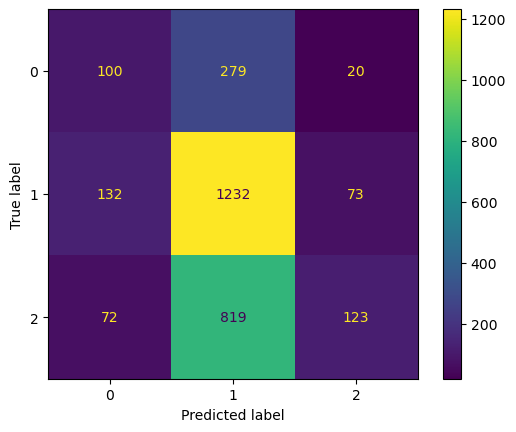

In [799]:
# Getting the combined confusion matrix for a prediction threshold of 0.45
disp = ConfusionMatrixDisplay(cf_overall_0_45.astype(int))
disp.plot()
plt.show()

And once again, we see that our Class 2 predictions are quite good, and our Class 0 predictions are not so much. Overall, we'll need to analyze exactly how much we would have made or lost had we gone in based on our model predictions, as these numbers only tell us whether or not the stock ended up closing higher or lower than the Open (or stayed roughly the same) for that particular day. This data does NOT tell us how large the difference between the two prices are.

# Conclusions for Final LSTM Models with the Correct Data Splits
Overall, after we split the training, validation, and test data properly by their Day numbers, we obtained significantly worse results than we had with any previous LSTM model. This makes quite a bit of sense, as we no longer trained on the most recent days in our dataset, which likely had pretty high price movement correlation between all the stocks. Without learning those trends for those latter days in our revised set of training data, our model seemed to have a much harder time generalizing to future days (i.e., our test data). Even with a threshold that our softmax predictions had to meet in order to be classified as Class 0 or Class 2, our results were barely better than any sort of baseline. Re-training the model (with sliding train/val/test windows) for each new day did produce some useable results, and we got some decent precision in our test accuracies for Class 0 and Class 2. However, this model took 30 minutes to run for each day, and there's essentially no way to speed up the process.

Nevertheless, we at least saw that with certain prediction thresholds, our model may be able to determine our two main classes with a non-trivial degree of accuracy, and we may be able to use this model to predict new price data from 2025. We will evaluate that in our final notebook, and this officially concludes the model testing phase of our project.

Lastly, we included a similar statement in the previous PCA-LSTM notebook as well, but we wanted to mention some next steps that we can potentially take if we were to continue this project further.

# Next Steps
Overall, we have collectively run dozens of models, only a portion of which have been shown in these notebooks. There are an endless number of things to try, but as we only have so much time to work on this project - and we do want to see an end - we will conclude the model testing here.

If we were to continue this project, below are some next steps that we could have taken:
 - Adding more features to see 1) what those features do, and 2) if PCA would perform better with them
 - Implementing an early stopping callback to get the models to not overfit
 - Trying embeddings with sector features
 - Utilizing the functional API for multiple output heads
 - Try testing with GRUs as well instead of just LSTMs
 - Testing with transformer models